In [1]:
import os
os.environ["DDE_BACKEND"] = "tensorflow.compat.v1"

import deepxde as dde


Using backend: tensorflow.compat.v1
Other supported backends: tensorflow, pytorch, jax, paddle.
paddle supports more examples now and is recommended.



Instructions for updating:
non-resource variables are not supported in the long term


In [2]:
# import deepxde as dde
import matplotlib.pyplot as plt
import numpy as np
import h5py
from sklearn.model_selection import train_test_split
import deepxde as dde
import matplotlib.pyplot as plt
import numpy as np
import h5py
from sklearn.model_selection import train_test_split

from mpl_toolkits.mplot3d import Axes3D

In [3]:
datastore = h5py.File("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/trials_many_alldata_new_eqution_halton_multinoise.h5", 'r')

print(list(datastore.keys()))

predictions_c_enhanced_pca = np.array(np.array(datastore["predictions_c_enhanced_pca"]))
predictions_c_enhanced_pca_experimental = np.array(np.array(datastore["predictions_c_enhanced_pca_experimental"]))
predictions_c_enhanced_pca_glob = np.array(np.array(datastore["predictions_c_enhanced_pca_glob"]))

predictions_c_ffn = np.array(np.array(datastore["predictions_c_ffn"]))
predictions_c_ffn_experimental = np.array(np.array(datastore["predictions_c_ffn_calculated"]))
predictions_c_ffn_glob = np.array(np.array(datastore["predictions_c_ffn_glob"]))

predictions_c_pca = np.array(np.array(datastore["predictions_c_pca"]))
predictions_c_pca_experimental = np.array(np.array(datastore["predictions_c_pca_experimental"]))
predictions_c_pca_glob = np.array(np.array(datastore["predictions_c_glob_pca"]))

predictions_h_enhanced_pca = np.array(np.array(datastore["predictions_h_enhanced_pca"]))
predictions_h_enhanced_pca_experimental = np.array(np.array(datastore["predictions_h_enhanced_pca_experimental"]))
predictions_h_enhanced_pca_glob = np.array(np.array(datastore["predictions_h_enhanced_pca_glob"]))

predictions_h_ffn = np.array(np.array(datastore["predictions_h_ffn"]))
predictions_h_ffn_experimental = np.array(np.array(datastore["predictions_h_ffn_calculated"]))
predictions_h_ffn_glob = np.array(np.array(datastore["predictions_h_ffn_glob"]))

predictions_h_pca = np.array(np.array(datastore["predictions_h_pca"]))
predictions_h_pca_experimental = np.array(np.array(datastore["predictions_h_pca_experimental"]))
predictions_h_pca_glob = np.array(np.array(datastore["predictions_h_glob_pca"]))

c_large = np.array(np.array(datastore["c_large"]))
h_large = np.array(np.array(datastore["h_large"]))
f_large = np.array(np.array(datastore["f_large"]))

data_p = np.array(np.array(datastore["parameters_large: J_e, b_1, b_2, h_e, f_0, Pc, phi, h0, ts"]))

t = np.linspace(0, 1, 601).reshape(601, 1)
data_f0 = data_p[:, 4] * 1e3
data_ts = data_p[:, 8]
data_h0 = data_p[:, 7] * 1e6

['I_clean', 'I_large', 'c', 'c_large', 'f', 'f_large', 'h', 'h_large', 'parameters: J_e, b_1, b_2, h_e, f_0, Pc, phi, h0, ts', 'parameters_large: J_e, b_1, b_2, h_e, f_0, Pc, phi, h0, ts', 'predictions_I_enhanced_pca_experimental', 'predictions_c_enhanced_pca', 'predictions_c_enhanced_pca_experimental', 'predictions_c_enhanced_pca_glob', 'predictions_c_ffn', 'predictions_c_ffn_calculated', 'predictions_c_ffn_glob', 'predictions_c_glob_pca', 'predictions_c_pca', 'predictions_c_pca_experimental', 'predictions_h_enhanced_pca', 'predictions_h_enhanced_pca_experimental', 'predictions_h_enhanced_pca_glob', 'predictions_h_ffn', 'predictions_h_ffn_calculated', 'predictions_h_ffn_glob', 'predictions_h_glob_pca', 'predictions_h_pca', 'predictions_h_pca_experimental']


In [4]:
print(np.array(np.array(datastore["I_large"])).shape, )

(193566, 601)


In [5]:
train_label_2, test_label_2 = train_test_split(range(len(c_large)), test_size=0.25, random_state=42)


data_c_2_train = c_large[train_label_2]
data_c_2_test = c_large[test_label_2]

data_h_2_train = h_large[train_label_2]
data_h_2_test = h_large[test_label_2]

data_f_2_train = f_large[train_label_2]
data_f_2_test = f_large[test_label_2]

data_f0_train = data_f0[train_label_2]
data_f0_test = data_f0[test_label_2]

data_ts_train = data_ts[train_label_2]
data_ts_test = data_ts[test_label_2]

data_h0_train = data_h0[train_label_2]
data_h0_test = data_h0[test_label_2]

In [6]:
datastore_glob = h5py.File("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/PDE_1d_glob_new_center_filtered.jld2", 'r')
data_I_glob = np.array(np.array(datastore_glob["filtered_data_I"]))

data_c_glob = np.array(np.array(datastore_glob["filtered_data_c"]))
data_h_glob = np.array(np.array(datastore_glob["filtered_data_h"]))

data_p_glob = np.array(np.array(datastore_glob["filtered_para"]))
data_ts_glob = data_p_glob[:,0].reshape(-1, 1)
data_h0_glob = data_p_glob[:,1].reshape(-1, 1)
data_f0_glob = data_p_glob[:,2].reshape(-1, 1)

data_d_sigma_0_glob = data_p_glob[:,3].reshape(-1, 1)
data_ri_glob = data_p_glob[:,4].reshape(-1, 1)
data_J_e_glob = data_p_glob[:,5].reshape(-1, 1)

datastore_glob.close()

In [7]:
datastore_experimental = h5py.File("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/experimental_data_nondimensional_2.h5", 'r')
data_I_calculated = np.array(datastore_experimental["calculated_I"])
data_h_calculated = np.array(datastore_experimental["calculated_h"])
data_f_calculated = np.array(datastore_experimental["calculated_f"])

data_c_caluculated = np.array(datastore_experimental["calculated_c"])
data_p_experimental_nondimensional = np.array(datastore_experimental["nondimensional_p"])

J_e_exp = data_p_experimental_nondimensional[:, 0]
b_1_exp = data_p_experimental_nondimensional[:, 1]
b_2_exp = data_p_experimental_nondimensional[:, 2]
h_e_exp = data_p_experimental_nondimensional[:, 3]
f0_data_exp = data_p_experimental_nondimensional[:, 4] * 1e3
Pc_exp = data_p_experimental_nondimensional[:, 5]
phi_exp = data_p_experimental_nondimensional[:, 6]
h0_data_exp = data_p_experimental_nondimensional[:, 7] * 1e6
ts_data_exp = data_p_experimental_nondimensional[:, 8]
residual_exp = data_p_experimental_nondimensional[:, 9] 

datastore_experimental.close()  # Close the read-only handle

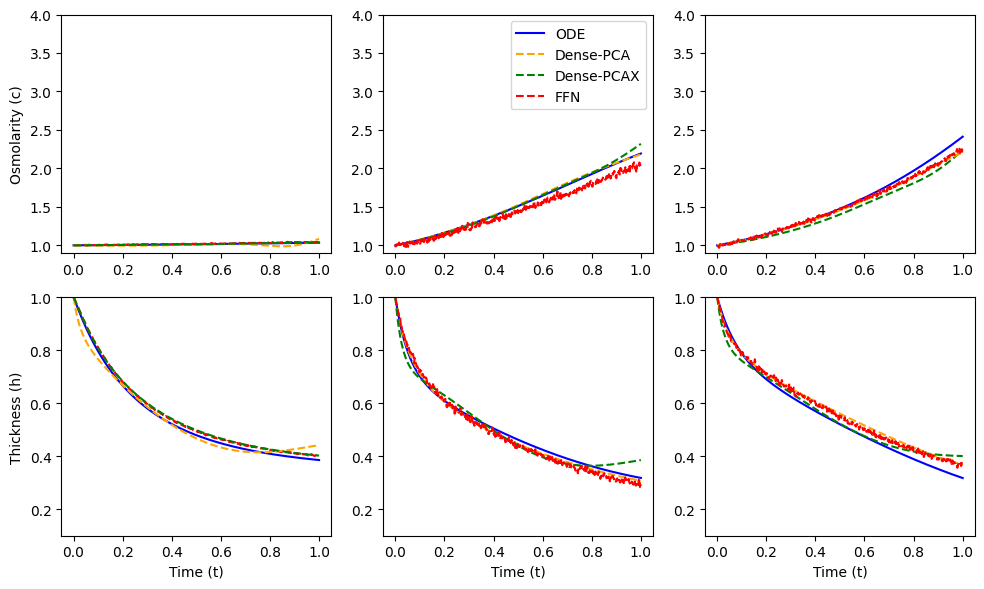

In [8]:
n1, n2, n3 = np.random.randint(len(data_c_2_test), size=3)

fig, ax = plt.subplots(2, 3, figsize=(10, 6))

ax[0, 0].plot(t, data_c_2_test[n1], label='ODE', color='blue')
ax[0, 0].plot(t, predictions_c_ffn[n1], label='FFN', linestyle='--', color='red')
ax[0, 0].plot(t, predictions_c_enhanced_pca[n1], label='Dense-PCA', linestyle='--', color='orange')
ax[0, 0].plot(t, predictions_c_pca[n1], label='Dense-PCAX', linestyle='--', color='green')
ax[0, 0].set_ylabel('Osmolarity (c)')
ax[0, 0].set_ylim(0.9, 4)
# ax[0, 0].legend()

ax[0, 1].plot(t, data_c_2_test[n2], label='ODE', color='blue')
ax[0, 1].plot(t, predictions_c_pca[n2], label='Dense-PCA', linestyle='--', color='orange')
ax[0, 1].plot(t, predictions_c_enhanced_pca[n2], label='Dense-PCAX', linestyle='--', color='green')
ax[0, 1].plot(t, predictions_c_ffn[n2], label='FFN', linestyle='--', color='red')
ax[0, 1].set_ylim(0.9, 4)
ax[0, 1].legend()

ax[0, 2].plot(t, data_c_2_test[n3], label='ODE', color='blue')
ax[0, 2].plot(t, predictions_c_enhanced_pca[n3], label='Dense-PCAX', linestyle='--', color='green')
ax[0, 2].plot(t, predictions_c_pca[n3], label='Dense-PCA', linestyle='--', color='orange')
ax[0, 2].plot(t, predictions_c_ffn[n3], label='FFN', linestyle='--', color='red')
ax[0, 2].set_ylim(0.9, 4)
# ax[0, 2].legend()

ax[1, 0].plot(t, data_h_2_test[n1], label='ODE', color='blue')
ax[1, 0].plot(t, predictions_h_ffn[n1], label='FFN', linestyle='--', color='red')
ax[1, 0].plot(t, predictions_h_enhanced_pca[n1], label='Dense-PCA', linestyle='--', color='orange')
ax[1, 0].plot(t, predictions_h_pca[n1], label='Dense-PCAX', linestyle='--', color='green')
ax[1, 0].set_xlabel('Time (t)')
ax[1, 0].set_ylabel('Thickness (h)')
ax[1, 0].set_ylim(0.1, 1)
# ax[1, 0].legend()

ax[1, 1].plot(t, data_h_2_test[n2], label='True thickness', color='blue')
ax[1, 1].plot(t, predictions_h_pca[n2], label='Dense-PCA', linestyle='--', color='orange')
ax[1, 1].plot(t, predictions_h_enhanced_pca[n2], label='Dense-PCAX', linestyle='--', color='green')
ax[1, 1].plot(t, predictions_h_ffn[n2], label='FFN', linestyle='--', color='red')
ax[1, 1].set_xlabel('Time (t)')
ax[1, 1].set_ylim(0.1, 1)
# ax[1, 1].legend()

ax[1, 2].plot(t, data_h_2_test[n3], label='True thickness', color='blue')
ax[1, 2].plot(t, predictions_h_enhanced_pca[n3], label='Dense-PCAX', linestyle='--', color='green')
ax[1, 2].plot(t, predictions_h_pca[n3], label='Dense-PCA', linestyle='--', color='orange')
ax[1, 2].plot(t, predictions_h_ffn[n3], label='FFN', linestyle='--', color='red')
ax[1, 2].set_xlabel('Time (t)')
ax[1, 2].set_ylim(0.1, 1)
# ax[1, 2].legend()

plt.tight_layout()
plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/final/3_samples_comparison.pdf", dpi=600)
plt.show()

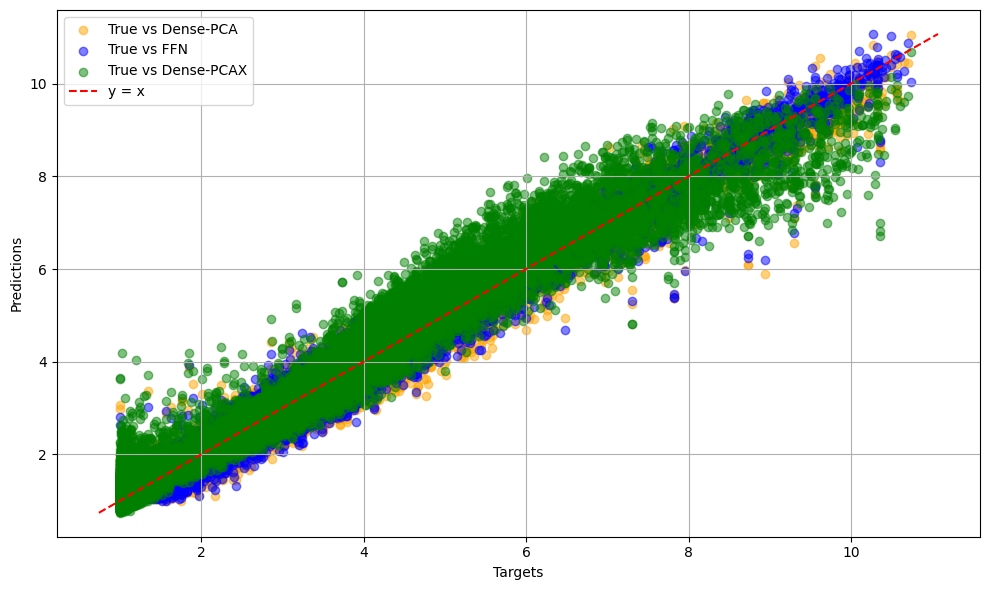

In [9]:
final_c_true = data_c_2_test[:len(data_c_2_test),-1].reshape(-1,1)
final_c_pca = predictions_c_pca[:len(data_c_2_test),-1].reshape(-1,1)
final_c_enhanced_pca = predictions_c_enhanced_pca[:len(data_c_2_test),-1].reshape(-1,1)
final_c_ffn = predictions_c_ffn[:len(data_c_2_test),-1].reshape(-1,1)

plt.figure(figsize=(10, 6))
plt.scatter(final_c_true, final_c_pca, label='True vs Dense-PCA', color='orange', alpha=0.5)
plt.scatter(final_c_true, final_c_ffn, label='True vs FFN', color='blue', alpha=0.5)
plt.scatter(final_c_true, final_c_enhanced_pca, label='True vs Dense-PCAX', color='green', alpha=0.5)
min_val = min(final_c_true.min(), final_c_pca.min(), final_c_enhanced_pca.min(), final_c_ffn.min())
max_val = max(final_c_true.max(), final_c_pca.max(), final_c_enhanced_pca.max(), final_c_ffn.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y = x')
plt.legend()
plt.xlabel('Targets')
plt.ylabel('Predictions')
# plt.title('Final Concentration: True vs Predicted (PCA Model)')
plt.grid(True)
plt.tight_layout()
plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/final/final_concentration_comparison.pdf", dpi=600)
plt.show()

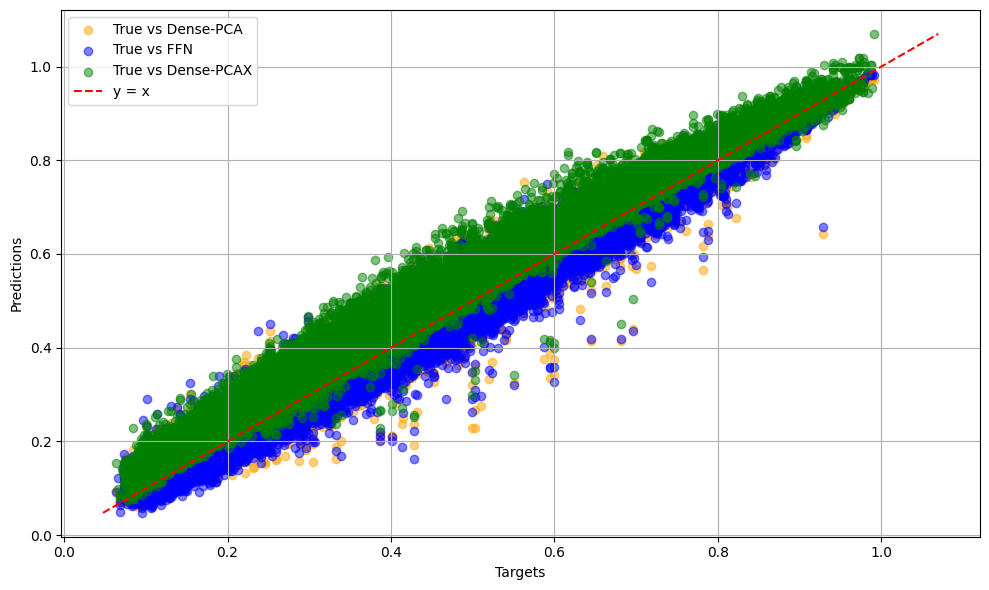

In [10]:
final_h_true = data_h_2_test[:len(data_h_2_test),-1].reshape(-1,1)
final_h_pca = predictions_h_pca[:len(data_h_2_test),-1].reshape(-1,1)
final_h_enhanced_pca = predictions_h_enhanced_pca[:len(data_h_2_test),-1].reshape(-1,1)
final_h_ffn = predictions_h_ffn[:len(data_h_2_test),-1].reshape(-1,1)

plt.figure(figsize=(10, 6))
plt.scatter(final_h_true, final_h_pca, label='True vs Dense-PCA', color='orange', alpha=0.5)
plt.scatter(final_h_true, final_h_ffn, label='True vs FFN', color='blue', alpha=0.5)
plt.scatter(final_h_true, final_h_enhanced_pca, label='True vs Dense-PCAX', color='green', alpha=0.5)
min_val = min(final_h_true.min(), final_h_pca.min(), final_h_enhanced_pca.min(), final_h_ffn.min())
max_val = max(final_h_true.max(), final_h_pca.max(), final_h_enhanced_pca.max(), final_h_ffn.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y = x')

plt.legend()
plt.xlabel('Targets')
plt.ylabel('Predictions')
# plt.title('Final Thickness: True vs Predicted (PCA Model)')
plt.grid(True)
plt.tight_layout()
plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/final/final_thickness_comparison.pdf", dpi=300)
plt.show()

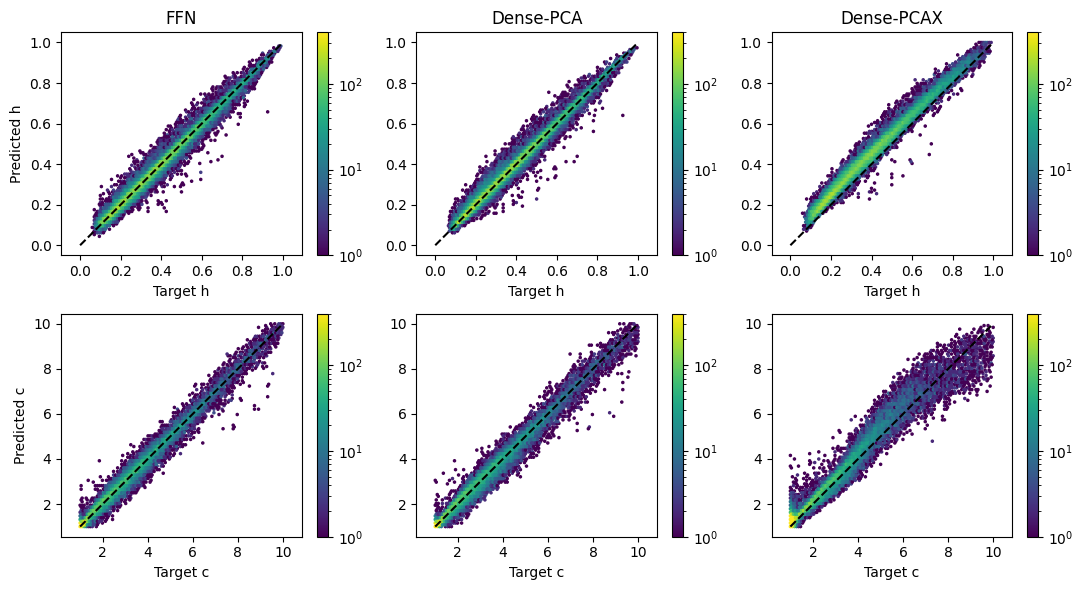

In [35]:
from matplotlib.colors import LogNorm

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(11, 6))
models = ["FFN", "Dense-PCA", "Dense-PCAX"]

for i in range(2):
    for j in range(3):
        if i == 0:
            target = final_h_true.flatten()
        else:
            target = final_c_true.flatten()
        if j == 0:
            pred = final_h_ffn.flatten() if i == 0 else final_c_ffn.flatten()
        elif j == 1:
            pred = final_h_pca.flatten() if i == 0 else final_c_pca.flatten()
        else:
            pred = final_h_enhanced_pca.flatten() if i == 0 else final_c_enhanced_pca.flatten()
        
        # To control the dot size, adjust the 'gridsize' parameter:
        # - Larger gridsize = smaller hexagons (dots)
        # - Smaller gridsize = larger hexagons (dots)
        # Example: gridsize=30 for larger dots, gridsize=80 for smaller dots
        min_val = min(target.min(), pred.min())
        max_val = max(target.max(), pred.max())
        
        hb = axs[i, j].hexbin(target, pred, gridsize=100, cmap='viridis', norm=LogNorm(vmin=1, vmax=400), mincnt=1, extent=(0,1,0,1) if i==0 else (1,10,1,10))
        # axs[i, j].plot([0, 1], [0, 1], color='black', linestyle='dashed')
        axs[i, j].axis('equal')
        if i == 0:
            axs[i, j].set_xlabel('Target h')
            axs[i, 0].set_ylabel('Predicted h')
            axs[i, j].set_title(models[j])
            axs[i, j].set_xticks(np.linspace(0, 1, 6))
            axs[i, j].set_yticks(np.linspace(0, 1, 6))
            axs[i, j].plot([0, 1], [0, 1], color='black', linestyle='dashed')
        
        else:
            axs[i, j].set_xlabel('Target c')
            axs[i, 0].set_ylabel('Predicted c')
            axs[i, j].set_xticks(np.linspace(0, 10, 6))
            axs[i, j].set_yticks(np.linspace(0, 10, 6))
            axs[i, j].plot([1, 10], [1, 10], color='black', linestyle='dashed')
    
        fig.colorbar(hb, ax=axs[i, j])

fig.tight_layout()
plt.show()


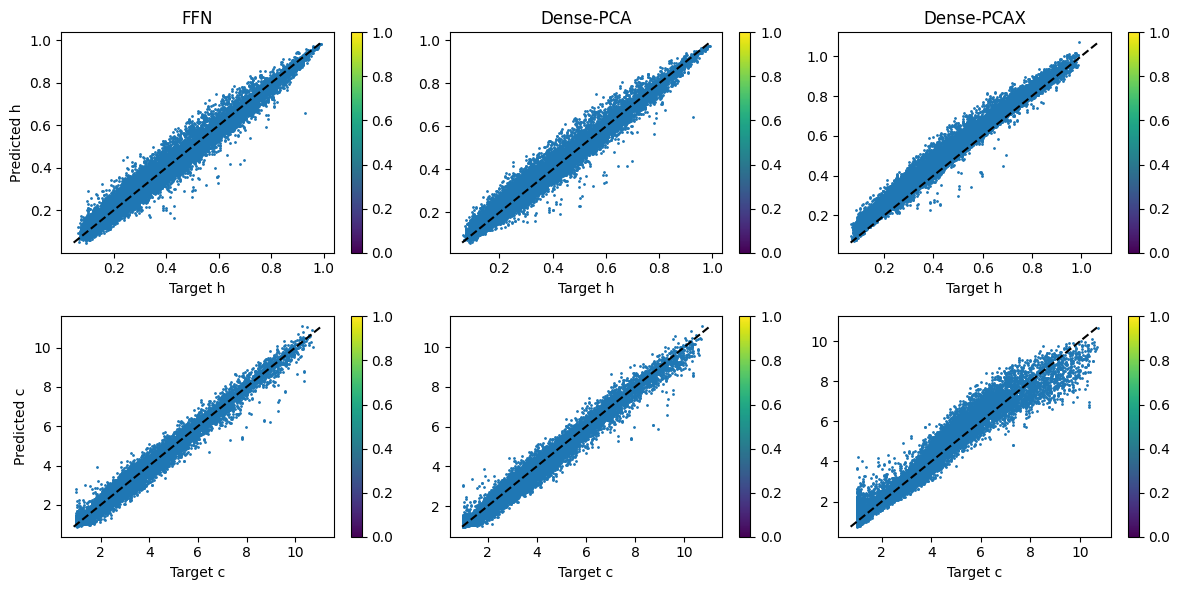

In [46]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(12, 6))
models = ["FFN", "Dense-PCA", "Dense-PCAX"]
for i in range(2):
    for j in range(3):
        # target = np.random.rand(30000)**1.25
        if i == 0:
            target = final_h_true.flatten()
        else:
            target = final_c_true.flatten()
        # a = 0.3 - 2 * np.random.rand()
        # pred = target - a*target + 0.25*np.random.randn(30000)
        if j == 0:
            if i == 0:
                pred = final_h_ffn.flatten()
            else:
                pred = final_c_ffn.flatten()
        elif j == 1:
            if i == 0:
                pred = final_h_pca.flatten()
            else:
                pred = final_c_pca.flatten()
        else:
            if i == 0:
                pred = final_h_enhanced_pca.flatten()
            else:
                pred = final_c_enhanced_pca.flatten()
        axs[i, j].scatter(target, pred, s=1)  # s controls marker size
        # Plot x=y line over the range of the data
        min_val = min(target.min(), pred.min())
        max_val = max(target.max(), pred.max())
        axs[i, j].plot([min_val, max_val], [min_val, max_val], color='black', linestyle='dashed')
        # axs[i, j].axis('equal')
        # axs[i, j].axis([1, 2, 0, 3])
        if i == 0:
            axs[i, j].set_xlabel('Target h')
            axs[i, 0].set_ylabel('Predicted h')
            axs[i, j].set_title(models[j])
        else:
            axs[i, j].set_xlabel('Target c')
            axs[i, 0].set_ylabel('Predicted c')
        plt.colorbar(axs[i, j].collections[0], ax=axs[i, j])
fig.tight_layout()

plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/final/scatter_final_h_c_comparison.pdf", dpi=600)
plt.show()

In [12]:
rrmse_c_pca = np.sqrt(np.sum((predictions_c_pca - data_c_2_test) ** 2, axis=1) / np.sum(data_c_2_test ** 2, axis=1))
rrmse_c_enhanced_pca = np.sqrt(np.sum((predictions_c_enhanced_pca - data_c_2_test) ** 2, axis=1) / np.sum(data_c_2_test ** 2, axis=1))
rrmse_c_ffn = np.sqrt(np.sum((predictions_c_ffn - data_c_2_test) ** 2, axis=1) / np.sum(data_c_2_test ** 2, axis=1))

rrmse_h_pca = np.sqrt(np.sum((predictions_h_pca - data_h_2_test) ** 2, axis=1) / np.sum(data_h_2_test ** 2, axis=1))
rrmse_h_enhanced_pca = np.sqrt(np.sum((predictions_h_enhanced_pca - data_h_2_test) ** 2, axis=1) / np.sum(data_h_2_test ** 2, axis=1))
rrmse_h_ffn = np.sqrt(np.sum((predictions_h_ffn - data_h_2_test) ** 2, axis=1) / np.sum(data_h_2_test ** 2, axis=1))

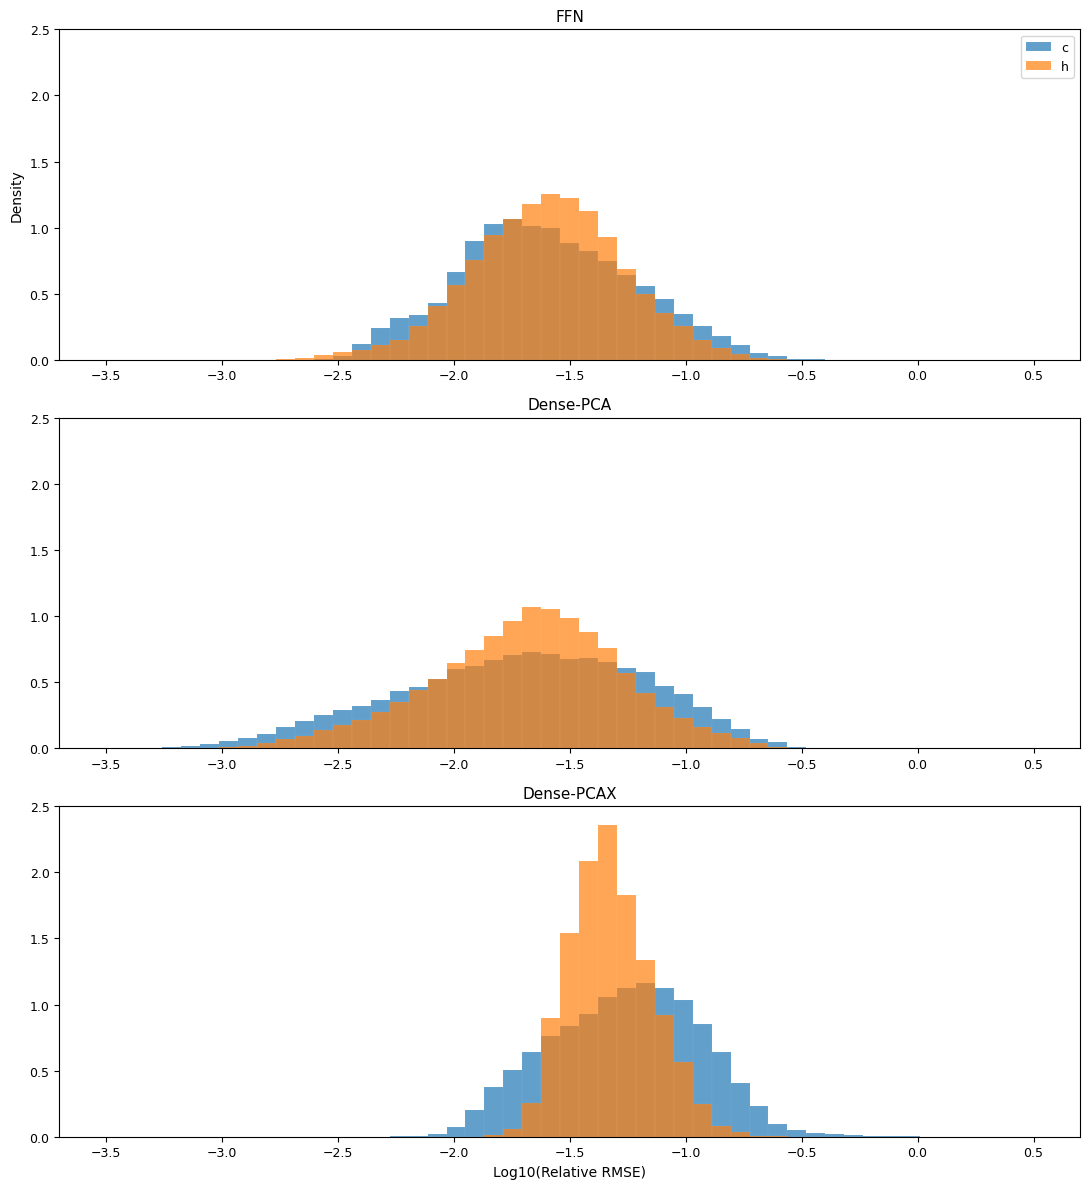

In [13]:
# Global font size
plt.rcParams.update({"font.size": 10})

fig, ax = plt.subplots(3, 1, figsize=(11, 12))

# Common histogram style
hist_kwargs = dict(
    bins=np.linspace(-3.5, 0.5, 50), # consistent bins
    alpha=0.7,
    density=True,      # use density on y-axis (frequency)
    edgecolor='white', # faint white edges
    linewidth=0.05      # make the borders thin
)

# ----- FFN -----
ax[0].hist(np.log10(rrmse_c_ffn), label='c', **hist_kwargs)
ax[0].hist(np.log10(rrmse_h_ffn), label='h', **hist_kwargs)
ax[0].set_ylim(0, 2.5)
ax[0].set_ylabel('Density', fontsize=10)
ax[0].set_title('FFN', fontsize=11)
ax[0].legend(fontsize=9)

# ----- PCA -----
ax[1].hist(np.log10(rrmse_c_pca), label='c', **hist_kwargs)
ax[1].hist(np.log10(rrmse_h_pca), label='h', **hist_kwargs)
ax[1].set_ylim(0, 2.5)
# ax[1].set_ylabel('Density', fontsize=10)
ax[1].set_title('Dense-PCA', fontsize=11)

# ----- Enhanced PCA -----
ax[2].hist(np.log10(rrmse_c_enhanced_pca), label='c', **hist_kwargs)
ax[2].hist(np.log10(rrmse_h_enhanced_pca), label='h', **hist_kwargs)
ax[2].set_xlabel('Log10(Relative RMSE)', fontsize=10)
ax[2].set_ylim(0, 2.5)
# ax[2].set_ylabel('Density', fontsize=10)
ax[2].set_title('Dense-PCAX', fontsize=11)

# Tick label font sizes
for a in ax:
    a.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig(
    "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/final/rrmse_histograms.pdf",
    dpi=600
)
plt.show()


In [14]:
rrmse_c_enhanced_pca_glob = np.sqrt(np.sum((predictions_c_enhanced_pca_glob - data_c_glob) ** 2, axis=1) / np.sum(data_c_glob ** 2, axis=1))
rrmse_h_enhanced_pca_glob = np.sqrt(np.sum((predictions_h_enhanced_pca_glob - data_h_glob) ** 2, axis=1) / np.sum(data_h_glob ** 2, axis=1))

rrmse_c_ffn_glob = np.sqrt(np.sum((predictions_c_ffn_glob - data_c_glob) ** 2, axis=1) / np.sum(data_c_glob ** 2, axis=1))
rrmse_h_ffn_glob = np.sqrt(np.sum((predictions_h_ffn_glob - data_h_glob) ** 2, axis=1) / np.sum(data_h_glob ** 2, axis=1))

rrmse_c_pca_glob = np.sqrt(np.sum((predictions_c_pca_glob - data_c_glob) ** 2, axis=1) / np.sum(data_c_glob ** 2, axis=1))
rrmse_h_pca_glob = np.sqrt(np.sum((predictions_h_pca_glob - data_h_glob) ** 2, axis=1) / np.sum(data_h_glob ** 2, axis=1))

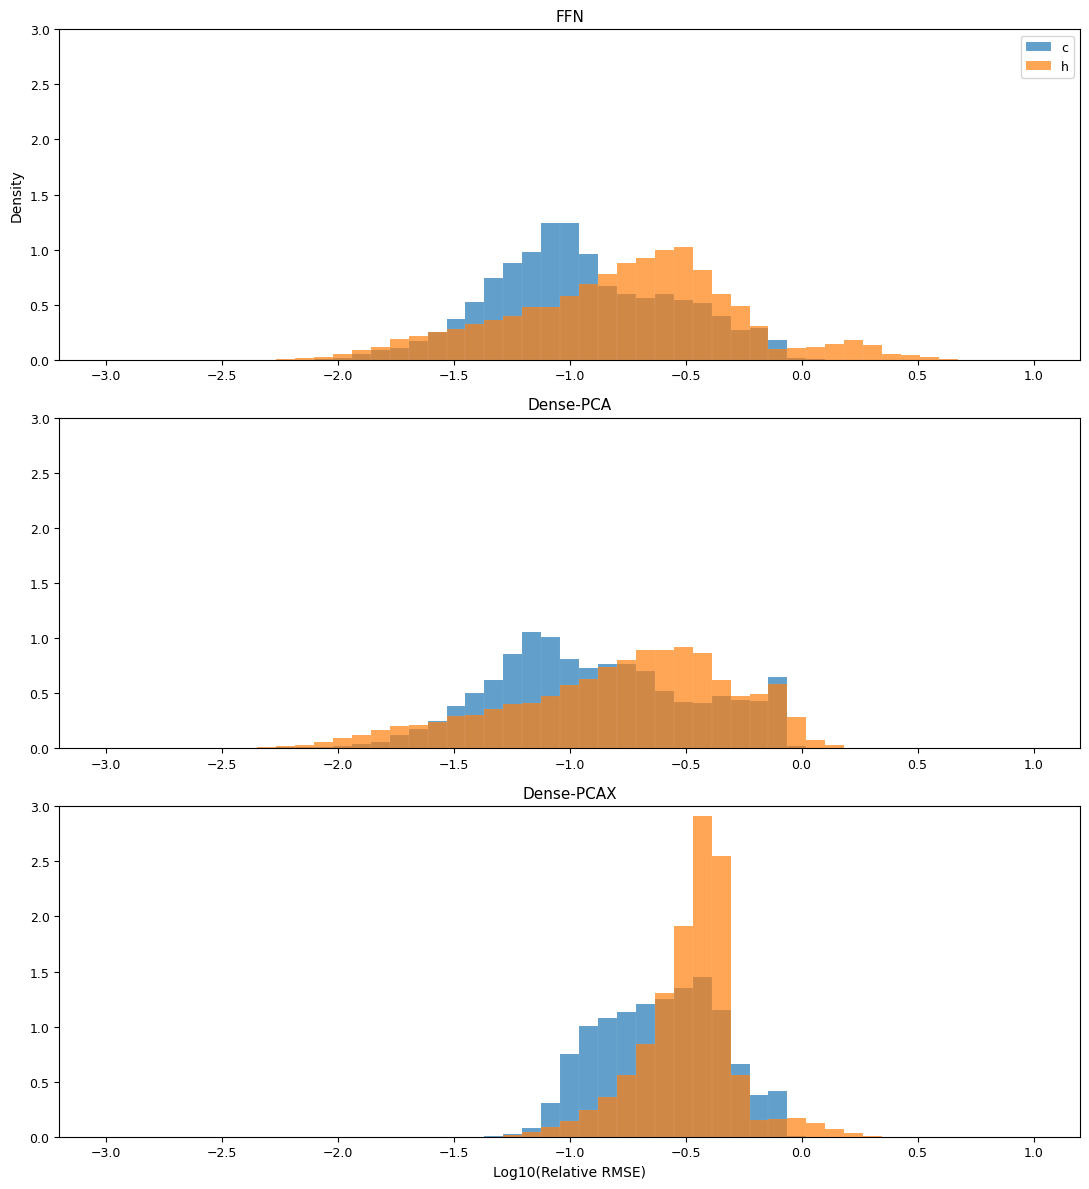

In [15]:
# Global font size
plt.rcParams.update({"font.size": 10})

fig, ax = plt.subplots(3, 1, figsize=(11, 12))

# Common histogram style
hist_kwargs = dict(
    bins=np.linspace(-3, 1, 50), # consistent bins
    
    alpha=0.7,
    density=True,      # use density on y-axis (frequency)
    edgecolor='white', # faint white edges
    linewidth=0.05      # make the borders thin
)

# ----- FFN -----
ax[0].hist(np.log10(rrmse_c_ffn_glob), label='c', **hist_kwargs)
ax[0].hist(np.log10(rrmse_h_ffn_glob), label='h', **hist_kwargs)
ax[0].set_ylim(0, 3)
ax[0].set_ylabel('Density', fontsize=10)
ax[0].set_title('FFN', fontsize=11)
ax[0].legend(fontsize=9)

# ----- PCA -----
ax[1].hist(np.log10(rrmse_c_pca_glob), label='c', **hist_kwargs)
ax[1].hist(np.log10(rrmse_h_pca_glob), label='h', **hist_kwargs)
ax[1].set_ylim(0, 3)
# ax[1].set_ylabel('Density', fontsize=10)
ax[1].set_title('Dense-PCA', fontsize=11)

# ----- Enhanced PCA -----
ax[2].hist(np.log10(rrmse_c_enhanced_pca_glob), label='c', **hist_kwargs)
ax[2].hist(np.log10(rrmse_h_enhanced_pca_glob), label='h', **hist_kwargs)
ax[2].set_xlabel('Log10(Relative RMSE)', fontsize=10)
ax[2].set_ylim(0, 3)
# ax[2].set_ylabel('Density', fontsize=10)
ax[2].set_title('Dense-PCAX', fontsize=11)

# Tick label font sizes
for a in ax:
    a.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/final/rrmse_histograms_glob.pdf", dpi=600)
plt.show()

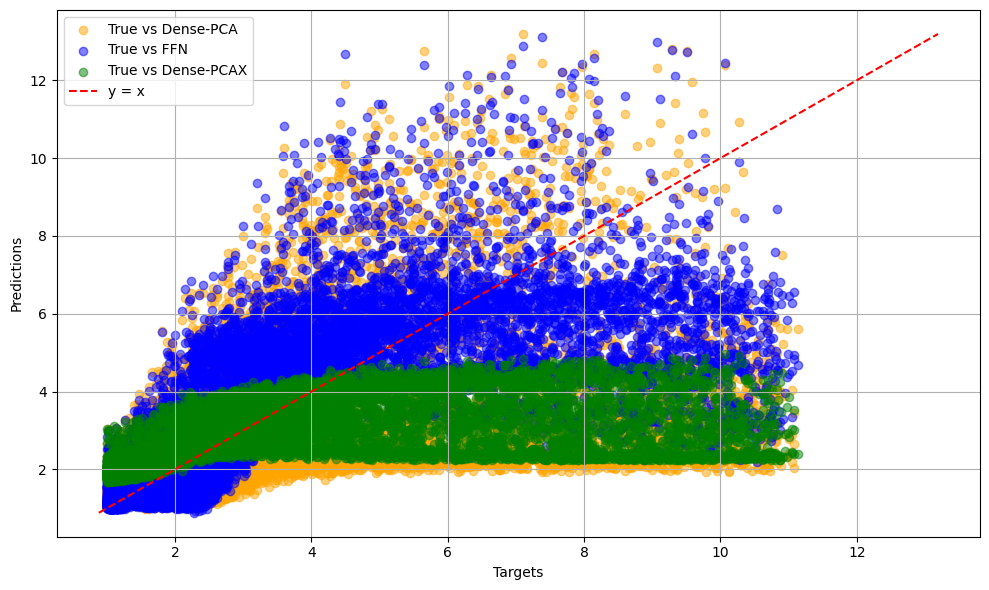

In [16]:
final_c_glob_true = data_c_glob[:,-1].reshape(-1,1)
final_c_glob_pca = predictions_c_pca_glob[:,-1].reshape(-1,1)
final_c_glob_enhanced_pca = predictions_c_enhanced_pca_glob[:,-1].reshape(-1,1)
final_c_glob_ffn = predictions_c_ffn_glob[:,-1].reshape(-1,1)

plt.figure(figsize=(10, 6))
plt.scatter(final_c_glob_true, final_c_glob_pca, label='True vs Dense-PCA', color='orange', alpha=0.5)
plt.scatter(final_c_glob_true, final_c_glob_ffn, label='True vs FFN', color='blue', alpha=0.5)
plt.scatter(final_c_glob_true, final_c_glob_enhanced_pca, label='True vs Dense-PCAX', color='green', alpha=0.5)
min_val = min(final_c_glob_true.min(), final_c_glob_pca.min(), final_c_glob_enhanced_pca.min(), final_c_glob_ffn.min())
max_val = max(final_c_glob_true.max(), final_c_glob_pca.max(), final_c_glob_enhanced_pca.max(), final_c_glob_ffn.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y = x')
plt.legend()
plt.xlabel('Targets')
plt.ylabel('Predictions')
# plt.title('Final Concentration: True vs Predicted (PCA Model) on Glob Data')
plt.grid(True)
plt.tight_layout()
plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/final/final_concentration_comparison_glob.pdf", dpi=600)
plt.show()

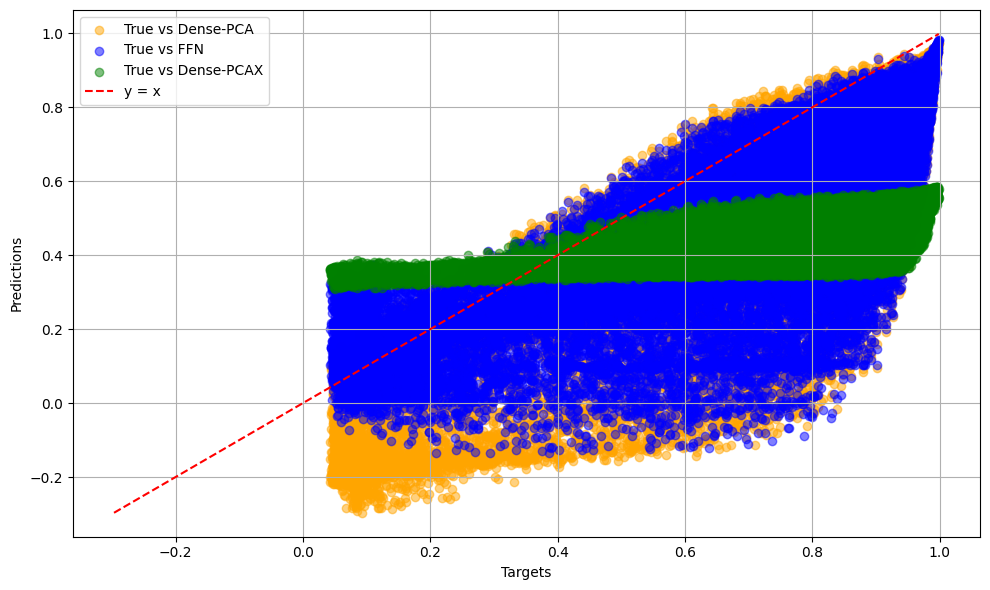

In [17]:
final_h_glob_true = data_h_glob[:,-1].reshape(-1,1)
final_h_glob_pca = predictions_h_pca_glob[:,-1].reshape(-1,1)
final_h_glob_enhanced_pca = predictions_h_enhanced_pca_glob[:,-1].reshape(-1,1)
final_h_glob_ffn = predictions_h_ffn_glob[:,-1].reshape(-1,1)
plt.figure(figsize=(10, 6))
plt.scatter(final_h_glob_true, final_h_glob_pca, label='True vs Dense-PCA', color='orange', alpha=0.5)
plt.scatter(final_h_glob_true, final_h_glob_ffn, label='True vs FFN', color='blue', alpha=0.5)
plt.scatter(final_h_glob_true, final_h_glob_enhanced_pca, label='True vs Dense-PCAX', color='green', alpha=0.5)
min_val = min(final_h_glob_true.min(), final_h_glob_pca.min(), final_h_glob_enhanced_pca.min(), final_h_glob_ffn.min())
max_val = max(final_h_glob_true.max(), final_h_glob_pca.max(), final_h_glob_enhanced_pca.max(), final_h_glob_ffn.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y = x')
plt.legend()
plt.xlabel('Targets')
plt.ylabel('Predictions')
# plt.title('Final Thickness: True vs Predicted (PCA Model) on Glob Data')
plt.grid(True)
plt.tight_layout()
plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/final/final_thickness_comparison_glob.pdf", dpi=600)
plt.show()

In [18]:
datastore_glob = h5py.File("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/PDE_1d_glob_new_center_filtered.jld2", 'r')
data_I_glob = np.array(np.array(datastore_glob["filtered_data_I"]))

data_c_glob = np.array(np.array(datastore_glob["filtered_data_c"]))
data_h_glob = np.array(np.array(datastore_glob["filtered_data_h"]))

data_p_glob = np.array(np.array(datastore_glob["filtered_para"]))
data_ts_glob = data_p_glob[:,0].reshape(-1, 1)
data_h0_glob = data_p_glob[:,1].reshape(-1, 1)
data_f0_glob = data_p_glob[:,2].reshape(-1, 1)

data_d_sigma_0_glob = data_p_glob[:,3].reshape(-1, 1)
data_ri_glob = data_p_glob[:,4].reshape(-1, 1)
data_J_e_glob = data_p_glob[:,5].reshape(-1, 1)

datastore_glob.close()

In [19]:
# fig, ax = plt.subplots(3, 1, figsize=(14, 12))

# scatter_0 = ax[0].scatter(
#     data_J_e_glob,
#     data_d_sigma_0_glob,
#     # s=sizes_filtered,
#     c=rrmse_c_enhanced_pca_glob,
#     # cmap='viridis',
#     alpha=0.6,
#     edgecolors='w'
# )

# fig.colorbar(scatter_0, ax=ax[0], label='rrmse_c_calculated_clean')
# ax[0].set_xlabel('J_e_exp')
# ax[0].set_ylabel('d_sigma_0_exp')
# ax[0].set_title(r'Bubble Plot of $J_{e_{exp}}$ vs $d_{\sigma_0}$ (Glob data)')

# scatter_1 = ax[1].scatter(
#     data_J_e_glob,
#     data_ri_glob,
#     # s=sizes_filtered,
#     c=rrmse_h_enhanced_pca_glob,
#     # cmap='viridis',
#     alpha=0.6,
#     edgecolors='w'
# )

# fig.colorbar(scatter_1, ax=ax[1], label='rrmse_h_calculated_clean')
# ax[1].set_xlabel('J_e_exp')
# ax[1].set_ylabel('ri_exp')
# ax[1].set_title(r'Bubble Plot of $J_{e_{exp}}$ vs $r_{i_{exp}}$ (Glob data)')

# scatter_2 = ax[2].scatter(
#     data_ri_glob,
#     data_d_sigma_0_glob,
#     # s=sizes_filtered,
#     c=rrmse_c_enhanced_pca_glob,
#     # cmap='viridis',
#     alpha=0.6,
#     edgecolors='w'
# )

# fig.colorbar(scatter_2, ax=ax[2], label='rrmse_c_calculated_clean')
# ax[2].set_xlabel('ri_exp')
# ax[2].set_ylabel('d_sigma_0_exp')
# ax[2].set_title(r'Bubble Plot of $r_{i_{exp}}$ vs $d_{\sigma_0}$ (Glob data)')

# plt.tight_layout()
# plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/final/bubble_plots_c_error_glob.png", dpi=300)
# plt.show()

In [20]:
# fig, ax = plt.subplots(3, 1, figsize=(14, 12))

# scatter_0 = ax[0].scatter(
#     data_J_e_glob,
#     data_d_sigma_0_glob,
#     # s=sizes_filtered,
#     c=rrmse_h_enhanced_pca_glob,
#     # cmap='viridis',
#     alpha=0.6,
#     edgecolors='w'
# )

# plt.colorbar(scatter_0, ax=ax[0], label='rrmse_h_calculated_clean')
# ax[0].set_xlabel('J_e_exp')
# ax[0].set_ylabel('d_sigma_0_exp')
# ax[0].set_title(r'Bubble Plot of $J_{e_{exp}}$ vs $d_{\sigma_0}$ (Glob data)')

# scatter_1 = ax[1].scatter(
#     data_J_e_glob,
#     data_ri_glob,
#     # s=sizes_filtered,
#     c=rrmse_h_enhanced_pca_glob,
#     # cmap='viridis',
#     alpha=0.6,
#     edgecolors='w'
# )

# plt.colorbar(scatter_1, ax=ax[1], label='rrmse_h_calculated_clean')
# ax[1].set_xlabel('J_e_exp')
# ax[1].set_ylabel('ri_exp')
# ax[1].set_title(r'Bubble Plot of $J_{e_exp}$ vs $r_{i_{exp}}$ (Glob data)')

# scatter_2 = ax[2].scatter(
#     data_ri_glob,
#     data_d_sigma_0_glob,
#     # s=sizes_filtered,
#     c=rrmse_h_enhanced_pca_glob,
#     # cmap='viridis',
#     alpha=0.6,
#     edgecolors='w'
# )

# plt.colorbar(scatter_2, ax=ax[2], label='rrmse_h_calculated_clean')
# ax[2].set_xlabel('ri_exp')
# ax[2].set_ylabel('d_sigma_0_exp')
# ax[2].set_title(r'Bubble Plot of $r_{i_{exp}}$ vs $d_{\sigma_0}$ (Glob data)')
# plt.tight_layout()
# plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/final/bubble_plots_h_error_glob.png", dpi=300)
# plt.show()

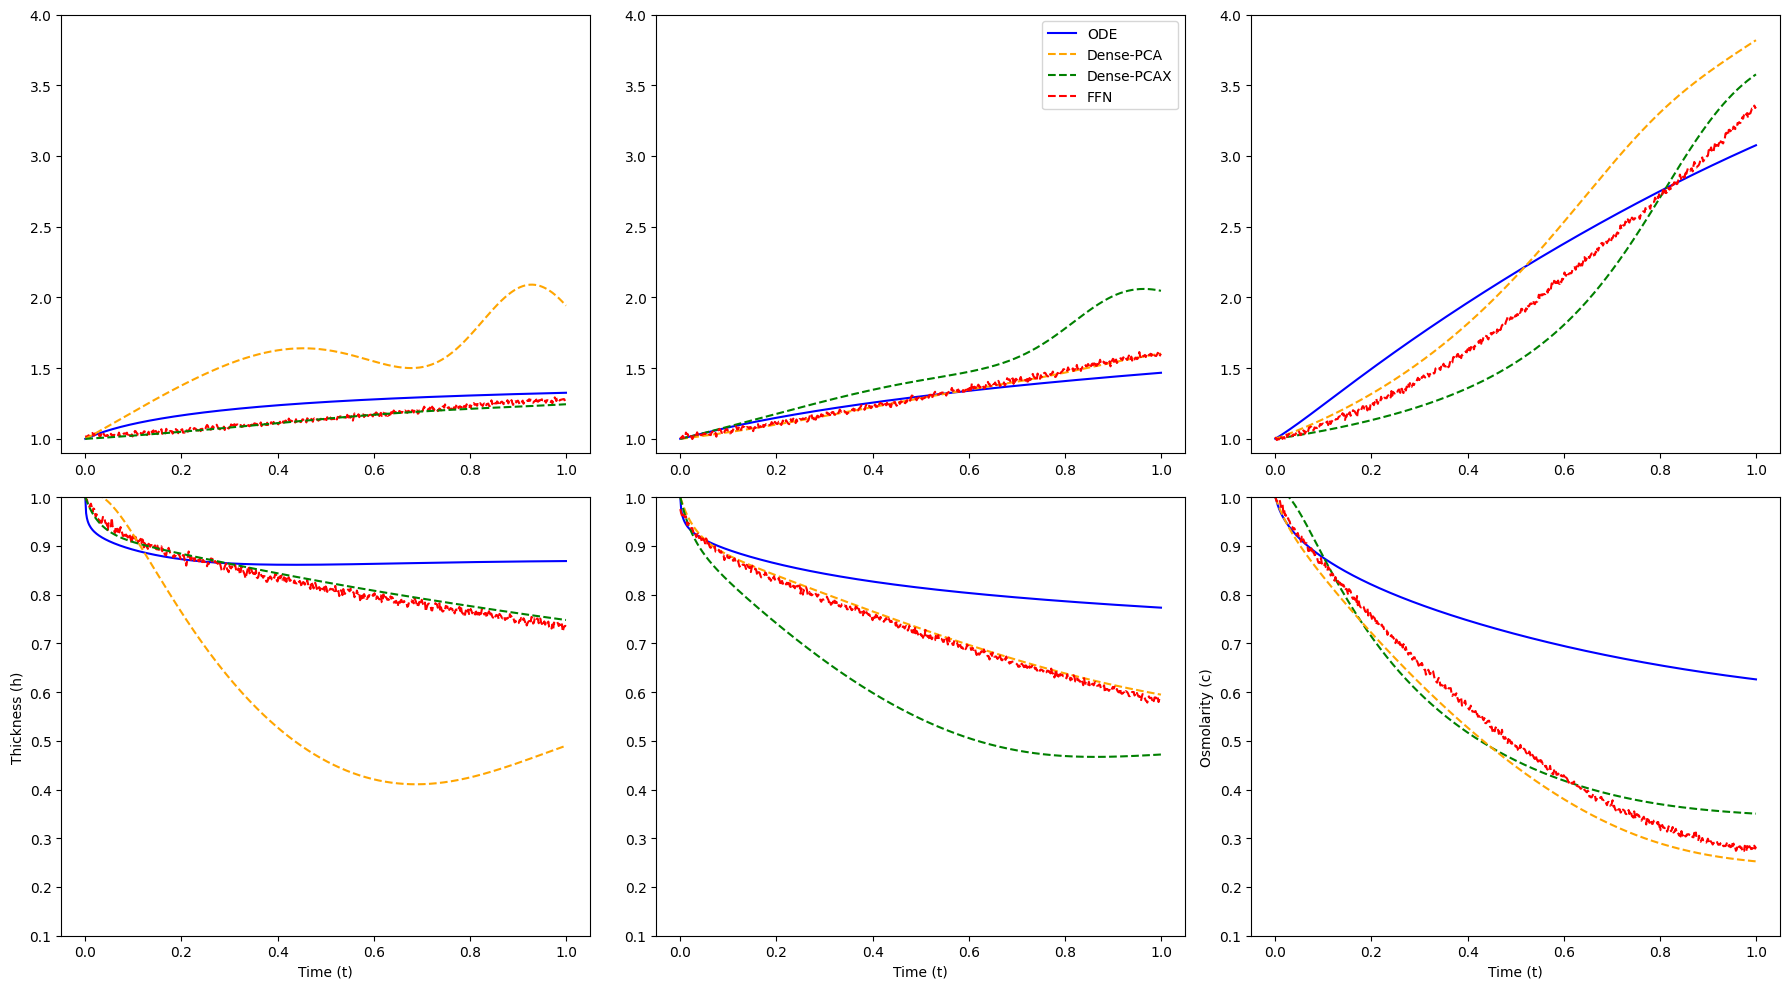

In [21]:
n1, n2, n3 = np.random.randint(len(data_c_glob), size=3)

fig, ax = plt.subplots(2, 3, figsize=(18, 10))

ax[0, 0].plot(t, data_c_glob[n1], label='ODE', color='blue')
ax[0, 0].plot(t, predictions_c_ffn_glob[n1], label='FFN', linestyle='--', color='red')
ax[0, 0].plot(t, predictions_c_enhanced_pca_glob[n1], label='Dense-PCA', linestyle='--', color='orange')
ax[0, 0].plot(t, predictions_c_pca_glob[n1], label='Dense-PCAX', linestyle='--', color='green')
plt.ylabel('Osmolarity (c)')
ax[0, 0].set_ylim(0.9, 4)
# ax[0, 0].legend()

ax[0, 1].plot(t, data_c_glob[n2], label='ODE', color='blue')
ax[0, 1].plot(t, predictions_c_pca_glob[n2], label='Dense-PCA', linestyle='--', color='orange')
ax[0, 1].plot(t, predictions_c_enhanced_pca_glob[n2], label='Dense-PCAX', linestyle='--', color='green')
ax[0, 1].plot(t, predictions_c_ffn_glob[n2], label='FFN', linestyle='--', color='red')
ax[0, 1].set_ylim(0.9, 4)
ax[0, 1].legend()

ax[0, 2].plot(t, data_c_glob[n3], label='ODE', color='blue')
ax[0, 2].plot(t, predictions_c_enhanced_pca_glob[n3], label='Enhanced PCA model', linestyle='--', color='green')
ax[0, 2].plot(t, predictions_c_pca_glob[n3], label='PCA model', linestyle='--', color='orange')
ax[0, 2].plot(t, predictions_c_ffn_glob[n3], label='FFN model', linestyle='--', color='red')
ax[0, 2].set_ylim(0.9, 4)
# ax[0, 2].legend()

ax[1, 0].plot(t, data_h_glob[n1], label='ODE', color='blue')
ax[1, 0].plot(t, predictions_h_ffn_glob[n1], label='FFN model', linestyle='--', color='red')
ax[1, 0].plot(t, predictions_h_enhanced_pca_glob[n1], label='PCA model', linestyle='--', color='orange')
ax[1, 0].plot(t, predictions_h_pca_glob[n1], label='Enhanced PCA model', linestyle='--', color='green')
ax[1, 0].set_xlabel('Time (t)')
ax[1, 0].set_ylabel('Thickness (h)')
ax[1, 0].set_ylim(0.1, 1)
# ax[1, 0].legend()

ax[1, 1].plot(t, data_h_glob[n2], label='ODE', color='blue')
ax[1, 1].plot(t, predictions_h_pca_glob[n2], label='PCA model', linestyle='--', color='orange')
ax[1, 1].plot(t, predictions_h_enhanced_pca_glob[n2], label='Enhanced PCA model', linestyle='--', color='green')
ax[1, 1].plot(t, predictions_h_ffn_glob[n2], label='FFN model', linestyle='--', color='red')
ax[1, 1].set_xlabel('Time (t)')
ax[1, 1].set_ylim(0.1, 1)
# ax[1, 1].legend()

ax[1, 2].plot(t, data_h_glob[n3], label='ODE', color='blue')
ax[1, 2].plot(t, predictions_h_enhanced_pca_glob[n3], label='Enhanced PCA model', linestyle='--', color='green')
ax[1, 2].plot(t, predictions_h_pca_glob[n3], label='PCA model', linestyle='--', color='orange')
ax[1, 2].plot(t, predictions_h_ffn_glob[n3], label='FFN model', linestyle='--', color='red')
ax[1, 2].set_xlabel('Time (t)')
ax[1, 2].set_ylim(0.1, 1)
# ax[1, 2].legend()

plt.tight_layout()
plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/final/3_samples_comparison_glob.pdf", dpi=600)
plt.show()


In [22]:
exprimental_data_path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/experimental_data_dimensional.txt"
exprimental_data_path_h5 = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/experimental_data_dimensional_2.h5"
exprimental_data_nondimensional_path_h5 = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/experimental_data_nondimensional_2.h5"

datastore = h5py.File(exprimental_data_nondimensional_path_h5, 'r')
print("Keys in the HDF5 file:", list(datastore.keys()))
data_I_calculated = np.array(datastore["calculated_I"])
data_h_calculated = np.array(datastore["calculated_h"])
data_f_calculated = np.array(datastore["calculated_f"])

data_c_caluculated = np.array(datastore["calculated_c"])
data_p_experimental_nondimensional = np.array(datastore["nondimensional_p"])

J_e_exp = data_p_experimental_nondimensional[:, 0]
b_1_exp = data_p_experimental_nondimensional[:, 1]
b_2_exp = data_p_experimental_nondimensional[:, 2]
h_e_exp = data_p_experimental_nondimensional[:, 3]
f0_data_exp = data_p_experimental_nondimensional[:, 4] * 1e3
Pc_exp = data_p_experimental_nondimensional[:, 5]
phi_exp = data_p_experimental_nondimensional[:, 6]
h0_data_exp = data_p_experimental_nondimensional[:, 7] * 1e6
ts_data_exp = data_p_experimental_nondimensional[:, 8]
residual_exp = data_p_experimental_nondimensional[:, 9] 

datastore.close()  # Close the read-only handle

Keys in the HDF5 file: ['calculated_I', 'calculated_c', 'calculated_f', 'calculated_h', 'nondimensional_p', 'predictions_c_ffn_calculated', 'predictions_h_ffn_calculated']


In [23]:
with h5py.File(exprimental_data_path_h5, 'r') as h5f:
    t = h5f['t'][:]
    I = h5f['I'][:]
    p = h5f['p'][:]
    
I_scaled = np.array([row / row[0] for row in I], dtype=object)


In [24]:
def scale_time_arrays(t):
    """
    Linearly scale each time array so that:
      - the first value becomes 0
      - the value equal to ts becomes 1

    Parameters:
    - t: list or array of 1D numpy arrays (ragged)
    - ts_array: 1D array of float, ts for each instance

    Returns:
    - t_scaled: list of scaled time arrays with same structure
    """
    t_scaled = []

    for i in range(len(t)):
        t_i = t[i]
        t0 = t_i[0]
        t_end = t_i[-1]  # Assuming ts is the last value in the array

        t_scaled_i = (t_i - t0) / (t_end - t0)
        t_scaled.append(t_scaled_i)

    return np.array(t_scaled, dtype=object)


In [25]:
with h5py.File(exprimental_data_path_h5, 'r') as h5f:
    t_group = h5f['t']
    # Structured array access for 'ts'
    ts_array = h5f['p']['ts']
    id_array = h5f['p']['id']

t_scaled = scale_time_arrays(t)


In [26]:
from scipy.interpolate import PchipInterpolator

# Interpolate each row of t_scaled and I_scaled to length 601
n_points = 601
t_uniform = np.linspace(0, 1, n_points)

t_scaled_interp = []
I_scaled_interp = []

for t_row, I_row in zip(t_scaled, I_scaled):
    # Interpolators
    t_interp = t_uniform  # target x-axis
    I_interp_func = PchipInterpolator(t_row, I_row)
    I_interp = I_interp_func(t_interp)
    t_scaled_interp.append(t_interp)
    I_scaled_interp.append(I_interp)

t_scaled_interp = np.array(t_scaled_interp)
I_scaled_interp = np.array(I_scaled_interp)

In [27]:
exprimental_data_path_h5 = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/experimental_data_dimensional_2.h5"


datastore_exp = h5py.File(exprimental_data_path_h5, 'r')
id_array = datastore_exp['p']['id']

datastore_exp.close()

In [28]:
t = np.linspace(0, 1, 601)

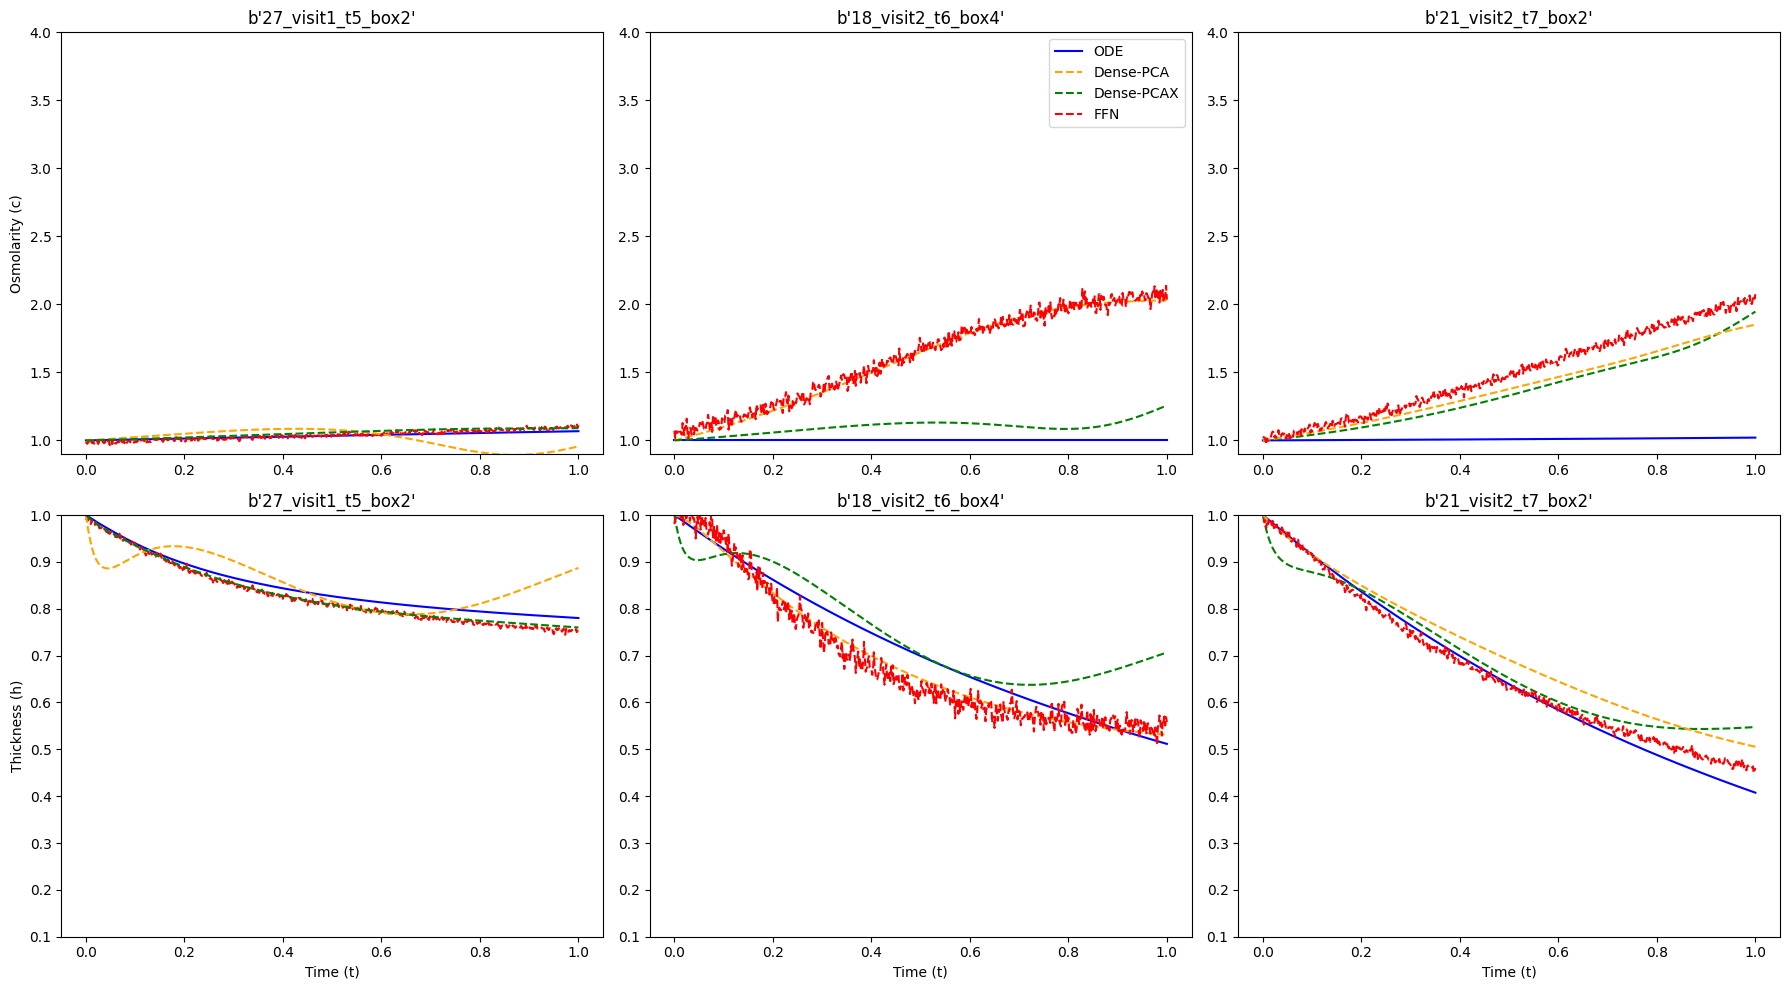

In [29]:
n1, n2, n3 = np.random.randint(len(data_c_caluculated), size=3)

fig, ax = plt.subplots(2, 3, figsize=(18, 10))

ax[0, 0].plot(t, data_c_caluculated[n1], label='ODE', color='blue')
ax[0, 0].plot(t, predictions_c_ffn_experimental[n1], label='FFN', linestyle='--', color='red')
ax[0, 0].plot(t, predictions_c_enhanced_pca_experimental[n1], label='Dense-PCA', linestyle='--', color='orange')
ax[0, 0].plot(t, predictions_c_pca_experimental[n1], label='Dense-PCAX', linestyle='--', color='green')
ax[0, 0].set_ylabel('Osmolarity (c)')
ax[0, 0].set_ylim(0.9, 4)
ax[0, 0].set_title(id_array[n1])
# ax[0, 0].legend()

ax[0, 1].plot(t, data_c_caluculated[n2], label='ODE', color='blue')
ax[0, 1].plot(t, predictions_c_pca_experimental[n2], label='Dense-PCA', linestyle='--', color='orange')
ax[0, 1].plot(t, predictions_c_enhanced_pca_experimental[n2], label='Dense-PCAX', linestyle='--', color='green')
ax[0, 1].plot(t, predictions_c_ffn_experimental[n2], label='FFN', linestyle='--', color='red')
ax[0, 1].set_ylim(0.9, 4)
ax[0, 1].set_title(id_array[n2])
ax[0, 1].legend()

ax[0, 2].plot(t, data_c_caluculated[n3], label='ODE', color='blue')
ax[0, 2].plot(t, predictions_c_enhanced_pca_experimental[n3], label='Enhanced PCA model', linestyle='--', color='green')
ax[0, 2].plot(t, predictions_c_pca_experimental[n3], label='PCA model', linestyle='--', color='orange')
ax[0, 2].plot(t, predictions_c_ffn_experimental[n3], label='FFN model', linestyle='--', color='red')
ax[0, 2].set_ylim(0.9, 4)
ax[0, 2].set_title(id_array[n3])
# ax[0, 2].legend()

ax[1, 0].plot(t, data_h_calculated[n1], label='ODE', color='blue')
ax[1, 0].plot(t, predictions_h_ffn_experimental[n1], label='FFN model', linestyle='--', color='red')
ax[1, 0].plot(t, predictions_h_enhanced_pca_experimental[n1], label='PCA model', linestyle='--', color='orange')
ax[1, 0].plot(t, predictions_h_pca_experimental[n1], label='Enhanced PCA model', linestyle='--', color='green')
ax[1, 0].set_xlabel('Time (t)')
ax[1, 0].set_ylabel('Thickness (h)')
ax[1, 0].set_ylim(0.1, 1)
ax[1, 0].set_title(id_array[n1])
# ax[1, 0].legend()

ax[1, 1].plot(t, data_h_calculated[n2], label='ODE', color='blue')
ax[1, 1].plot(t, predictions_h_pca_experimental[n2], label='PCA model', linestyle='--', color='orange')
ax[1, 1].plot(t, predictions_h_enhanced_pca_experimental[n2], label='Enhanced PCA model', linestyle='--', color='green')
ax[1, 1].plot(t, predictions_h_ffn_experimental[n2], label='FFN model', linestyle='--', color='red')
ax[1, 1].set_xlabel('Time (t)')
ax[1, 1].set_ylim(0.1, 1)
ax[1, 1].set_title(id_array[n2])
# ax[1, 1].legend()

ax[1, 2].plot(t, data_h_calculated[n3], label='ODE', color='blue')
ax[1, 2].plot(t, predictions_h_enhanced_pca_experimental[n3], label='Enhanced PCA model', linestyle='--', color='green')
ax[1, 2].plot(t, predictions_h_pca_experimental[n3], label='PCA model', linestyle='--', color='orange')
ax[1, 2].plot(t, predictions_h_ffn_experimental[n3], label='FFN model', linestyle='--', color='red')
ax[1, 2].set_xlabel('Time (t)')
ax[1, 2].set_ylim(0.1, 1)
ax[1, 2].set_title(id_array[n3])
# ax[1, 2].legend()

plt.tight_layout()
plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/final/3_samples_comparison_experimental.pdf", dpi=600)
plt.show()

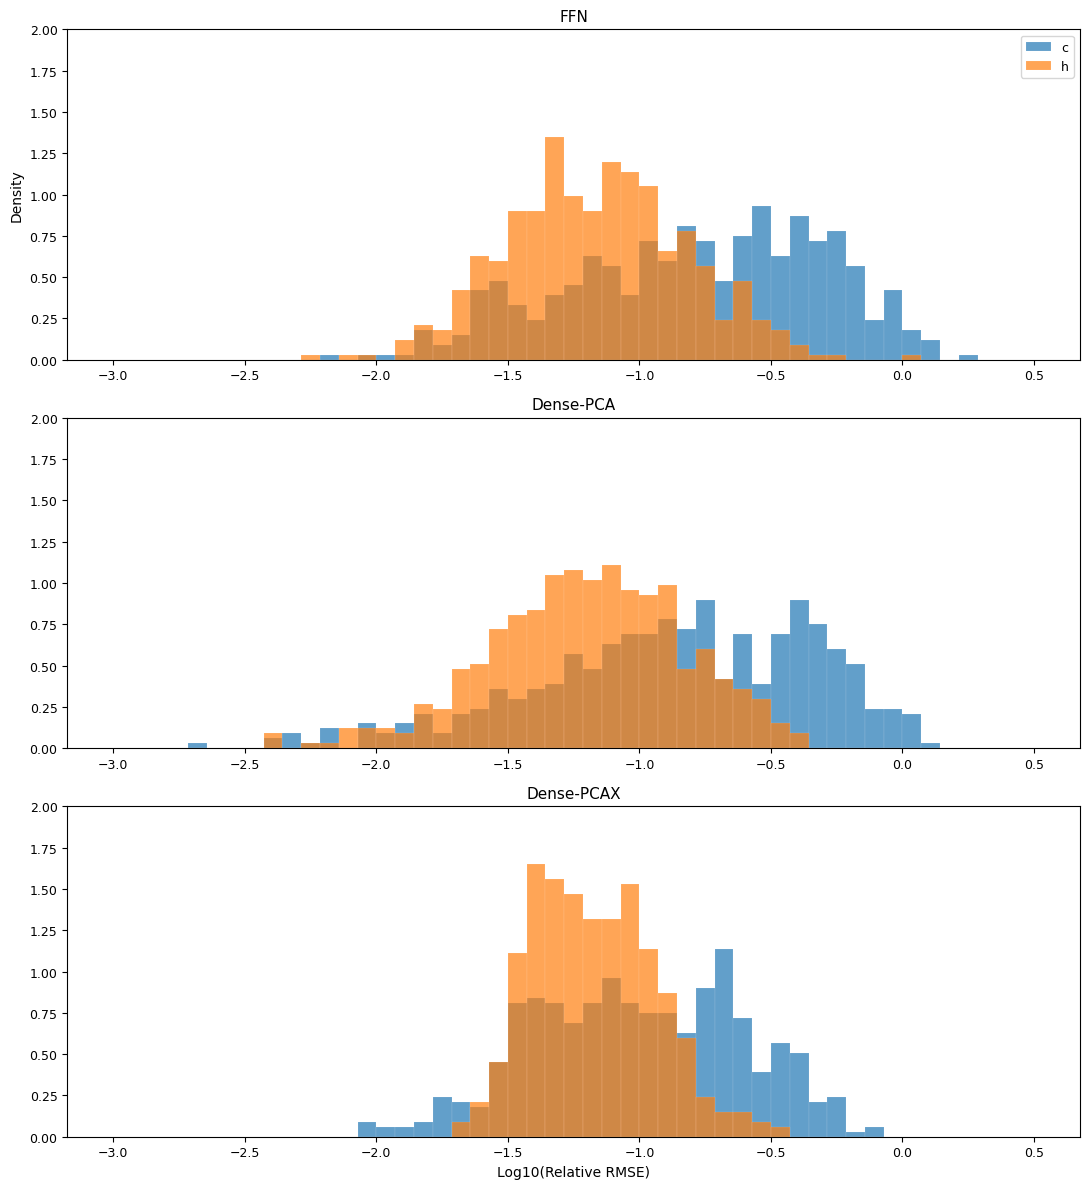

In [30]:
rrmse_c_enhanced_pca_experimental = np.sqrt(np.sum((predictions_c_enhanced_pca_experimental - data_c_caluculated) ** 2, axis=1) / np.sum(data_c_caluculated ** 2, axis=1))
rrmse_h_enhanced_pca_experimental = np.sqrt(np.sum((predictions_h_enhanced_pca_experimental - data_h_calculated) ** 2, axis=1) / np.sum(data_h_calculated ** 2, axis=1))

rrmse_c_pca_experimental = np.sqrt(np.sum((predictions_c_pca_experimental - data_c_caluculated) ** 2, axis=1) / np.sum(data_c_caluculated ** 2, axis=1))
rrmse_h_pca_experimental = np.sqrt(np.sum((predictions_h_pca_experimental - data_h_calculated) ** 2, axis=1) / np.sum(data_h_calculated ** 2, axis=1))

rrmse_c_ffn_experimental = np.sqrt(np.sum((predictions_c_ffn_experimental - data_c_caluculated) ** 2, axis=1) / np.sum(data_c_caluculated ** 2, axis=1))
rrmse_h_ffn_experimental = np.sqrt(np.sum((predictions_h_ffn_experimental - data_h_calculated) ** 2, axis=1) / np.sum(data_h_calculated ** 2, axis=1))

# Global font size
plt.rcParams.update({"font.size": 10})

fig, ax = plt.subplots(3, 1, figsize=(11, 12))

# Common histogram style
hist_kwargs = dict(
    bins=np.linspace(-3, 0.5, 50), # consistent bins
    alpha=0.7,
    density=True,      # use density on y-axis (frequency)
    edgecolor='white', # faint white edges
    linewidth=0.1      # make the borders thin
)

# ----- FFN -----
ax[0].hist(np.log10(rrmse_c_ffn_experimental), label='c', **hist_kwargs)
ax[0].hist(np.log10(rrmse_h_ffn_experimental), label='h', **hist_kwargs)
ax[0].set_ylim(0, 2)
ax[0].set_ylabel('Density', fontsize=10)
ax[0].set_title('FFN', fontsize=11)
ax[0].legend(fontsize=9)

# ----- PCA -----
ax[1].hist(np.log10(rrmse_c_pca_experimental), label='c', **hist_kwargs)
ax[1].hist(np.log10(rrmse_h_pca_experimental), label='h', **hist_kwargs)
ax[1].set_ylim(0, 2)
# ax[1].set_ylabel('Density', fontsize=10)
ax[1].set_title('Dense-PCA', fontsize=11)

# ----- Enhanced PCA -----
ax[2].hist(np.log10(rrmse_c_enhanced_pca_experimental), label='c', **hist_kwargs)
ax[2].hist(np.log10(rrmse_h_enhanced_pca_experimental), label='h', **hist_kwargs)
ax[2].set_xlabel('Log10(Relative RMSE)', fontsize=10)
ax[2].set_ylim(0, 2)
# ax[2].set_ylabel('Density', fontsize=10)
ax[2].set_title('Dense-PCAX', fontsize=11)

# Tick label font sizes
for a in ax:
    a.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/final/rrmse_histograms_experimental.pdf", dpi=600)
plt.show()

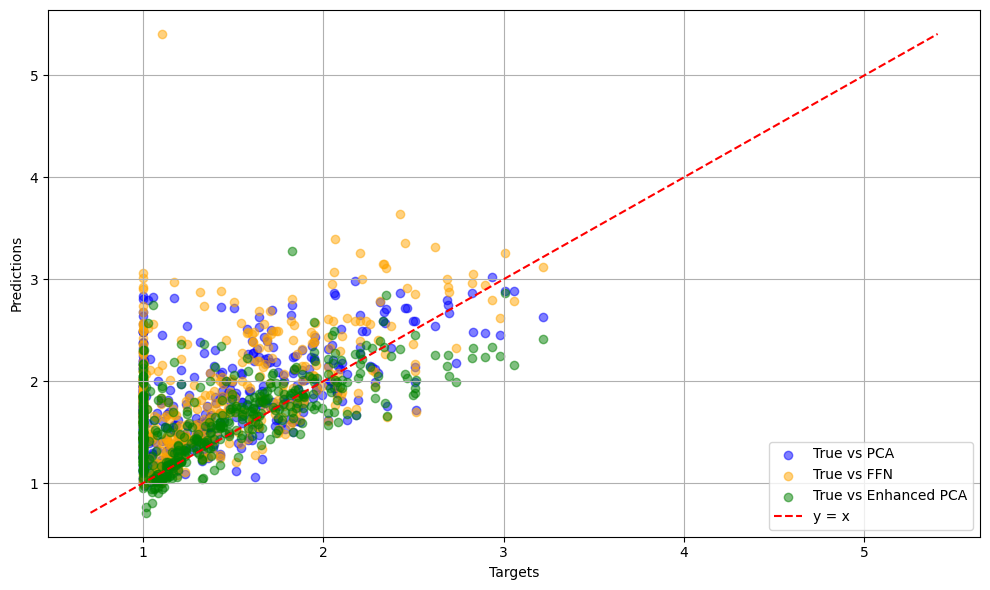

In [31]:
final_c_exp = data_c_caluculated[:,-1]
final_c_pca_exp = predictions_c_pca_experimental[:,-1]
final_c_enhanced_pca_exp = predictions_c_enhanced_pca_experimental[:,-1]
final_c_ffn_exp = predictions_c_ffn_experimental[:,-1]

plt.figure(figsize=(10, 6))
plt.scatter(final_c_exp, final_c_pca_exp, label='True vs PCA', color='blue', alpha=0.5)
plt.scatter(final_c_exp, final_c_ffn_exp, label='True vs FFN', color='orange', alpha=0.5)
plt.scatter(final_c_exp, final_c_enhanced_pca_exp, label='True vs Enhanced PCA', color='green', alpha=0.5)
min_val = min(final_c_exp.min(), final_c_pca_exp.min(), final_c_enhanced_pca_exp.min(), final_c_ffn_exp.min())
max_val = max(final_c_exp.max(), final_c_pca_exp.max(), final_c_enhanced_pca_exp.max(), final_c_ffn_exp.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y = x')
plt.legend()
plt.xlabel('Targets')
plt.ylabel('Predictions')
# plt.title('Final Concentration: True vs Predicted (PCA Model)')
plt.grid(True)
plt.tight_layout()
plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/final/final_concentration_comparison_experimental.pdf", dpi=600)
plt.show()

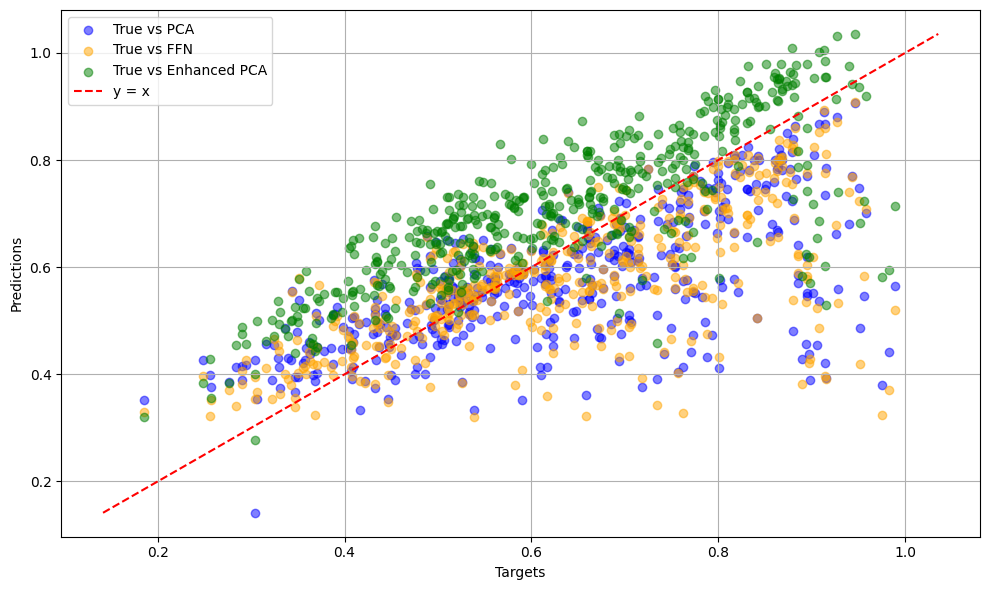

In [32]:
final_h_exp = data_h_calculated[:,-1]
final_h_pca_exp = predictions_h_pca_experimental[:,-1]
final_h_enhanced_pca_exp = predictions_h_enhanced_pca_experimental[:,-1]
final_h_ffn_exp = predictions_h_ffn_experimental[:,-1]

plt.figure(figsize=(10, 6))
plt.scatter(final_h_exp, final_h_pca_exp, label='True vs PCA', color='blue', alpha=0.5)
plt.scatter(final_h_exp, final_h_ffn_exp, label='True vs FFN', color='orange', alpha=0.5)
plt.scatter(final_h_exp, final_h_enhanced_pca_exp, label='True vs Enhanced PCA', color='green', alpha=0.5)
min_val = min(final_h_exp.min(), final_h_pca_exp.min(), final_h_enhanced_pca_exp.min(), final_h_ffn_exp.min())
max_val = max(final_h_exp.max(), final_h_pca_exp.max(), final_h_enhanced_pca_exp.max(), final_h_ffn_exp.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y = x')
plt.legend()
plt.xlabel('Targets')
plt.ylabel('Predictions')
# plt.title('Final Thickness: True vs Predicted (PCA Model)')
plt.grid(True)
plt.tight_layout()
plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/final/final_thickness_comparison_experimental.pdf", dpi=600)
plt.show()

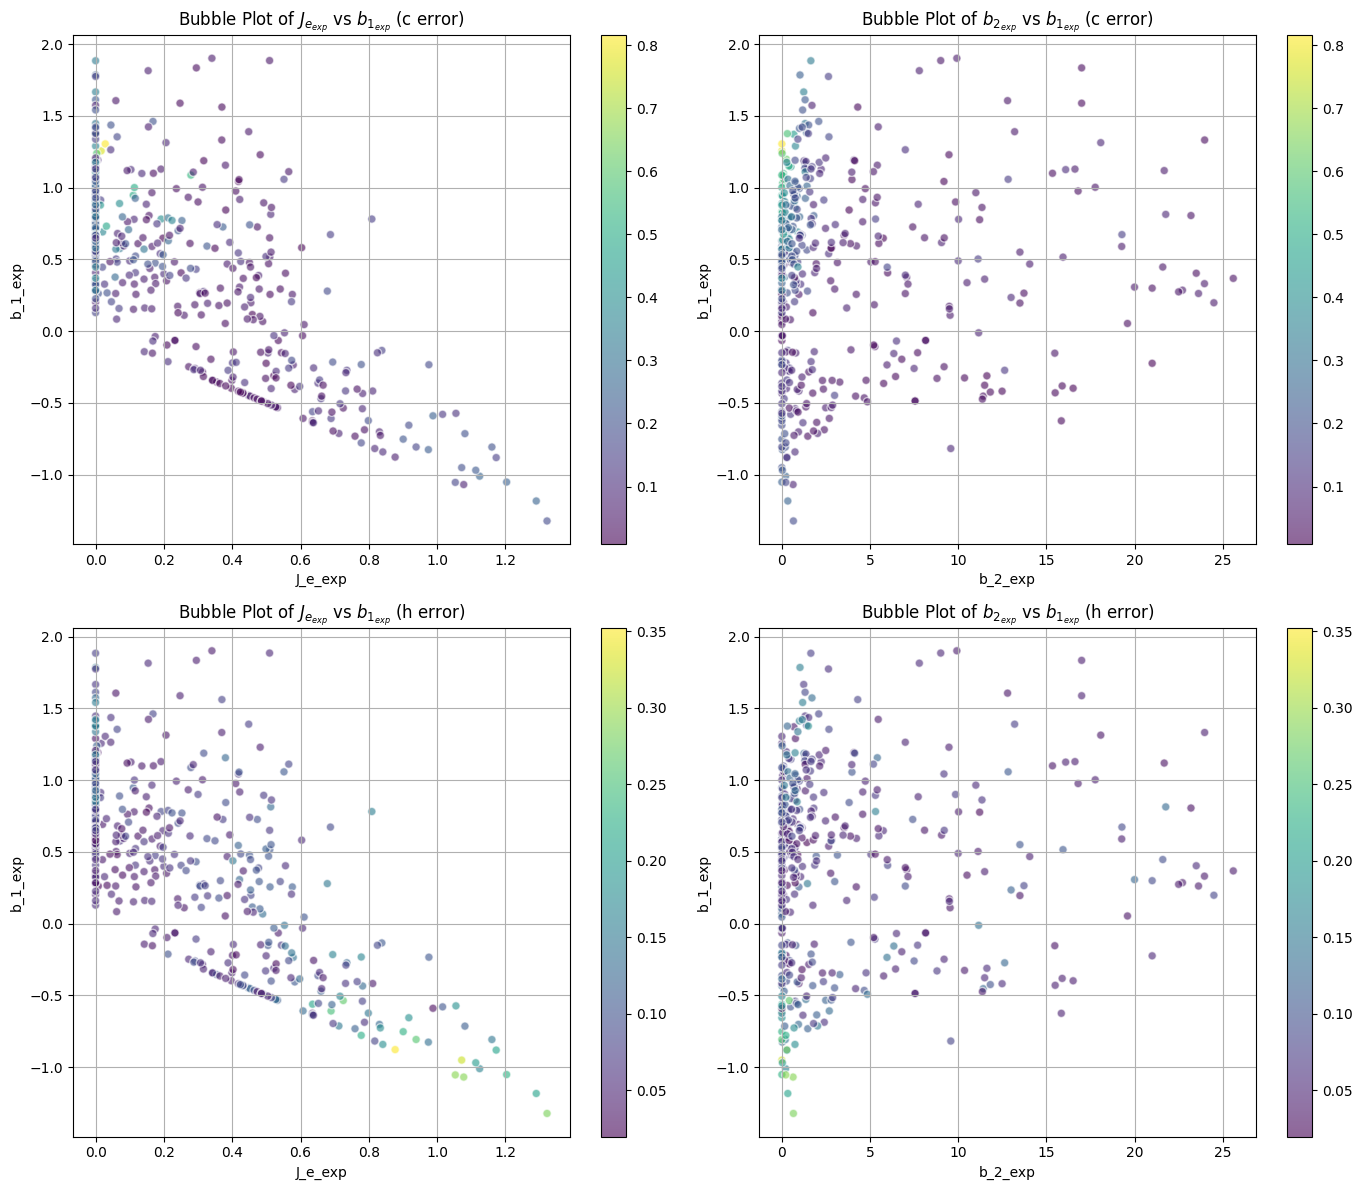

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# define threshold using 95th percentile
b1_threshold = np.percentile(b_1_exp, 95)
b2_threshold = np.percentile(b_2_exp, 95)

# keep only points below thresholds
mask = (b_1_exp < b1_threshold) & (b_2_exp < b2_threshold)

# filtered data
J_e_exp_f = J_e_exp[mask]
b_1_exp_f = b_1_exp[mask]
b_2_exp_f = b_2_exp[mask]
rrmse_c_f = rrmse_c_enhanced_pca_experimental[mask]
rrmse_h_f = rrmse_h_enhanced_pca_experimental[mask]

# same plotting code with filtered data
fig, ax = plt.subplots(2, 2, figsize=(14, 12))

scatter_0 = ax[0,0].scatter(
    J_e_exp_f, b_1_exp_f,
    c=rrmse_c_f, alpha=0.6, edgecolors='w'
)
fig.colorbar(scatter_0, ax=ax[0,0])
ax[0,0].set_xlabel('J_e_exp')
ax[0,0].set_ylabel('b_1_exp')
ax[0,0].set_title(r'Bubble Plot of $J_{e_{exp}}$ vs $b_{1_{exp}}$ (c error)')
ax[0,0].grid(True)

scatter_2 = ax[0,1].scatter(
    b_2_exp_f, b_1_exp_f,
    c=rrmse_c_f, alpha=0.6, edgecolors='w'
)
fig.colorbar(scatter_2, ax=ax[0,1])
ax[0,1].set_xlabel('b_2_exp')
ax[0,1].set_ylabel('b_1_exp')
ax[0,1].set_title(r'Bubble Plot of $b_{2_{exp}}$ vs $b_{1_{exp}}$ (c error)')
ax[0,1].grid(True)

scatter_0 = ax[1,0].scatter(
    J_e_exp_f, b_1_exp_f,
    c=rrmse_h_f, alpha=0.6, edgecolors='w'
)

fig.colorbar(scatter_0, ax=ax[1,0])
ax[1,0].set_xlabel('J_e_exp')
ax[1,0].set_ylabel('b_1_exp')
ax[1,0].set_title(r'Bubble Plot of $J_{e_{exp}}$ vs $b_{1_{exp}}$ (h error)')
ax[1,0].grid(True)


scatter_2 = ax[1,1].scatter(
    b_2_exp_f, b_1_exp_f,
    c=rrmse_h_f, alpha=0.6, edgecolors='w'
)

fig.colorbar(scatter_2, ax=ax[1,1])
ax[1,1].set_xlabel('b_2_exp')
ax[1,1].set_ylabel('b_1_exp')
ax[1,1].set_title(r'Bubble Plot of $b_{2_{exp}}$ vs $b_{1_{exp}}$ (h error)')
ax[1,1].grid(True)

plt.tight_layout()
plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/final/bubble_plots_experimental_filtered.pdf", dpi=600)
plt.show()


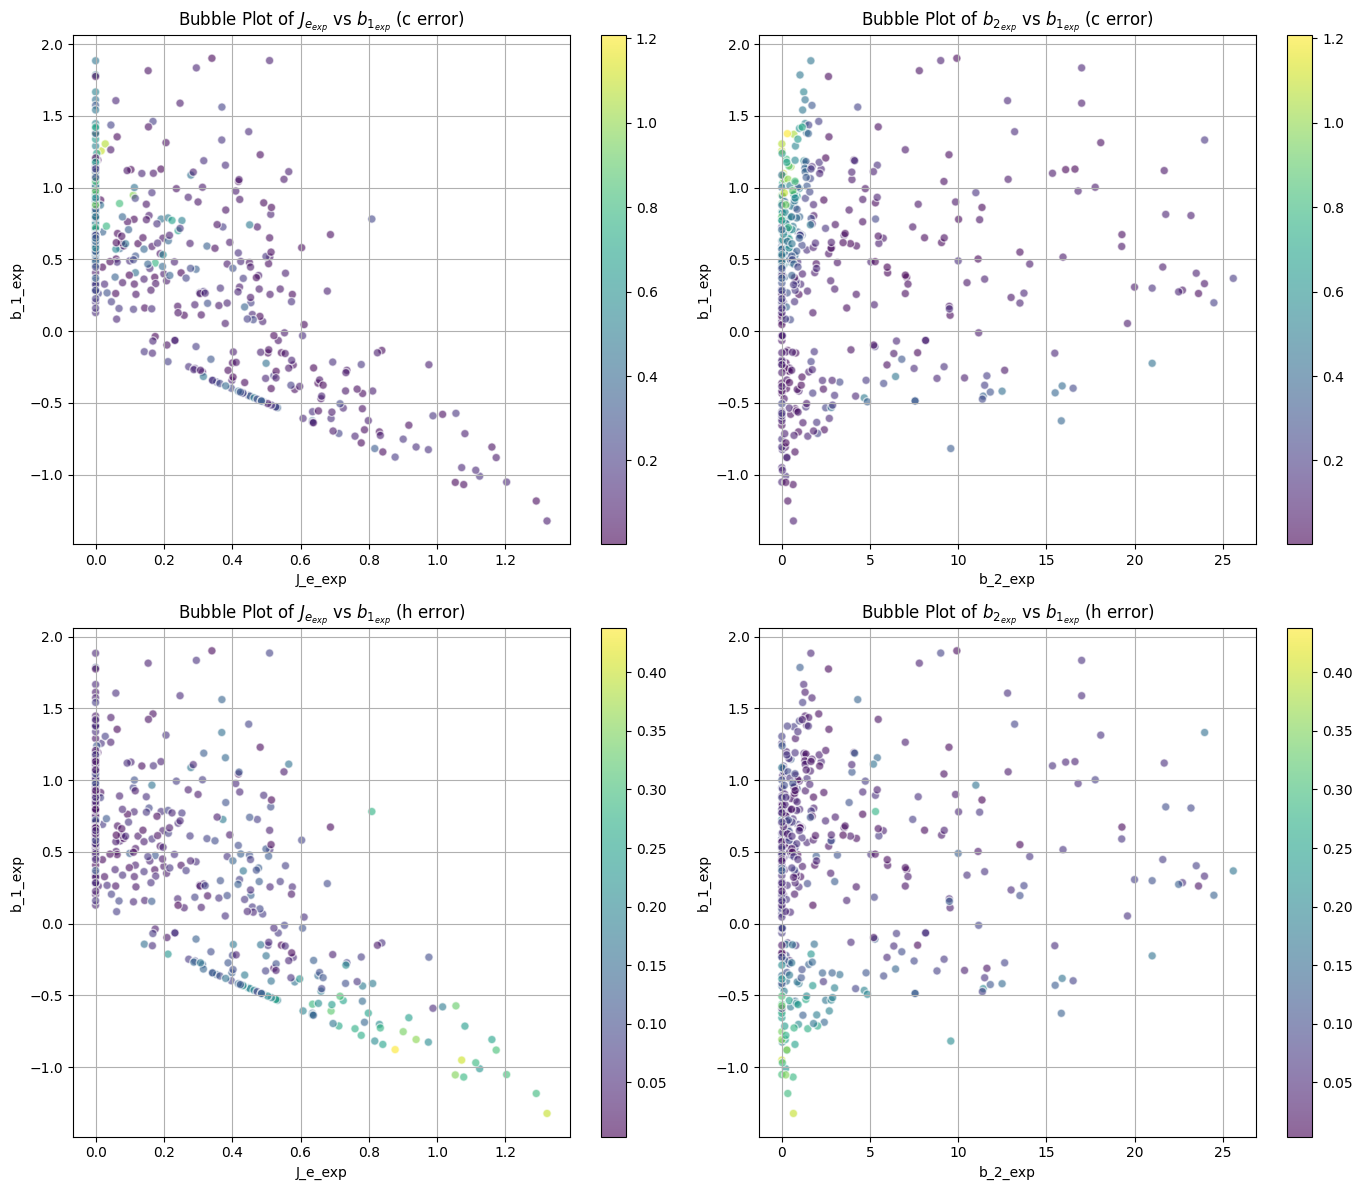

In [34]:
rrmse_c_f = rrmse_c_pca_experimental[mask]
rrmse_h_f = rrmse_h_pca_experimental[mask]

# same plotting code with filtered data
fig, ax = plt.subplots(2, 2, figsize=(14, 12))

scatter_0 = ax[0,0].scatter(
    J_e_exp_f, b_1_exp_f,
    c=rrmse_c_f, alpha=0.6, edgecolors='w'
)
fig.colorbar(scatter_0, ax=ax[0,0])
ax[0,0].set_xlabel('J_e_exp')
ax[0,0].set_ylabel('b_1_exp')
ax[0,0].set_title(r'Bubble Plot of $J_{e_{exp}}$ vs $b_{1_{exp}}$ (c error)')
ax[0,0].grid(True)

scatter_2 = ax[0,1].scatter(
    b_2_exp_f, b_1_exp_f,
    c=rrmse_c_f, alpha=0.6, edgecolors='w'
)
fig.colorbar(scatter_2, ax=ax[0,1])
ax[0,1].set_xlabel('b_2_exp')
ax[0,1].set_ylabel('b_1_exp')
ax[0,1].set_title(r'Bubble Plot of $b_{2_{exp}}$ vs $b_{1_{exp}}$ (c error)')
ax[0,1].grid(True)

scatter_0 = ax[1,0].scatter(
    J_e_exp_f, b_1_exp_f,
    c=rrmse_h_f, alpha=0.6, edgecolors='w'
)

fig.colorbar(scatter_0, ax=ax[1,0])
ax[1,0].set_xlabel('J_e_exp')
ax[1,0].set_ylabel('b_1_exp')
ax[1,0].set_title(r'Bubble Plot of $J_{e_{exp}}$ vs $b_{1_{exp}}$ (h error)')
ax[1,0].grid(True)


scatter_2 = ax[1,1].scatter(
    b_2_exp_f, b_1_exp_f,
    c=rrmse_h_f, alpha=0.6, edgecolors='w'
)

fig.colorbar(scatter_2, ax=ax[1,1])
ax[1,1].set_xlabel('b_2_exp')
ax[1,1].set_ylabel('b_1_exp')
ax[1,1].set_title(r'Bubble Plot of $b_{2_{exp}}$ vs $b_{1_{exp}}$ (h error)')
ax[1,1].grid(True)

plt.tight_layout()
plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/final/bubble_plots_experimental_filtered_pca.pdf", dpi=600)
plt.show()

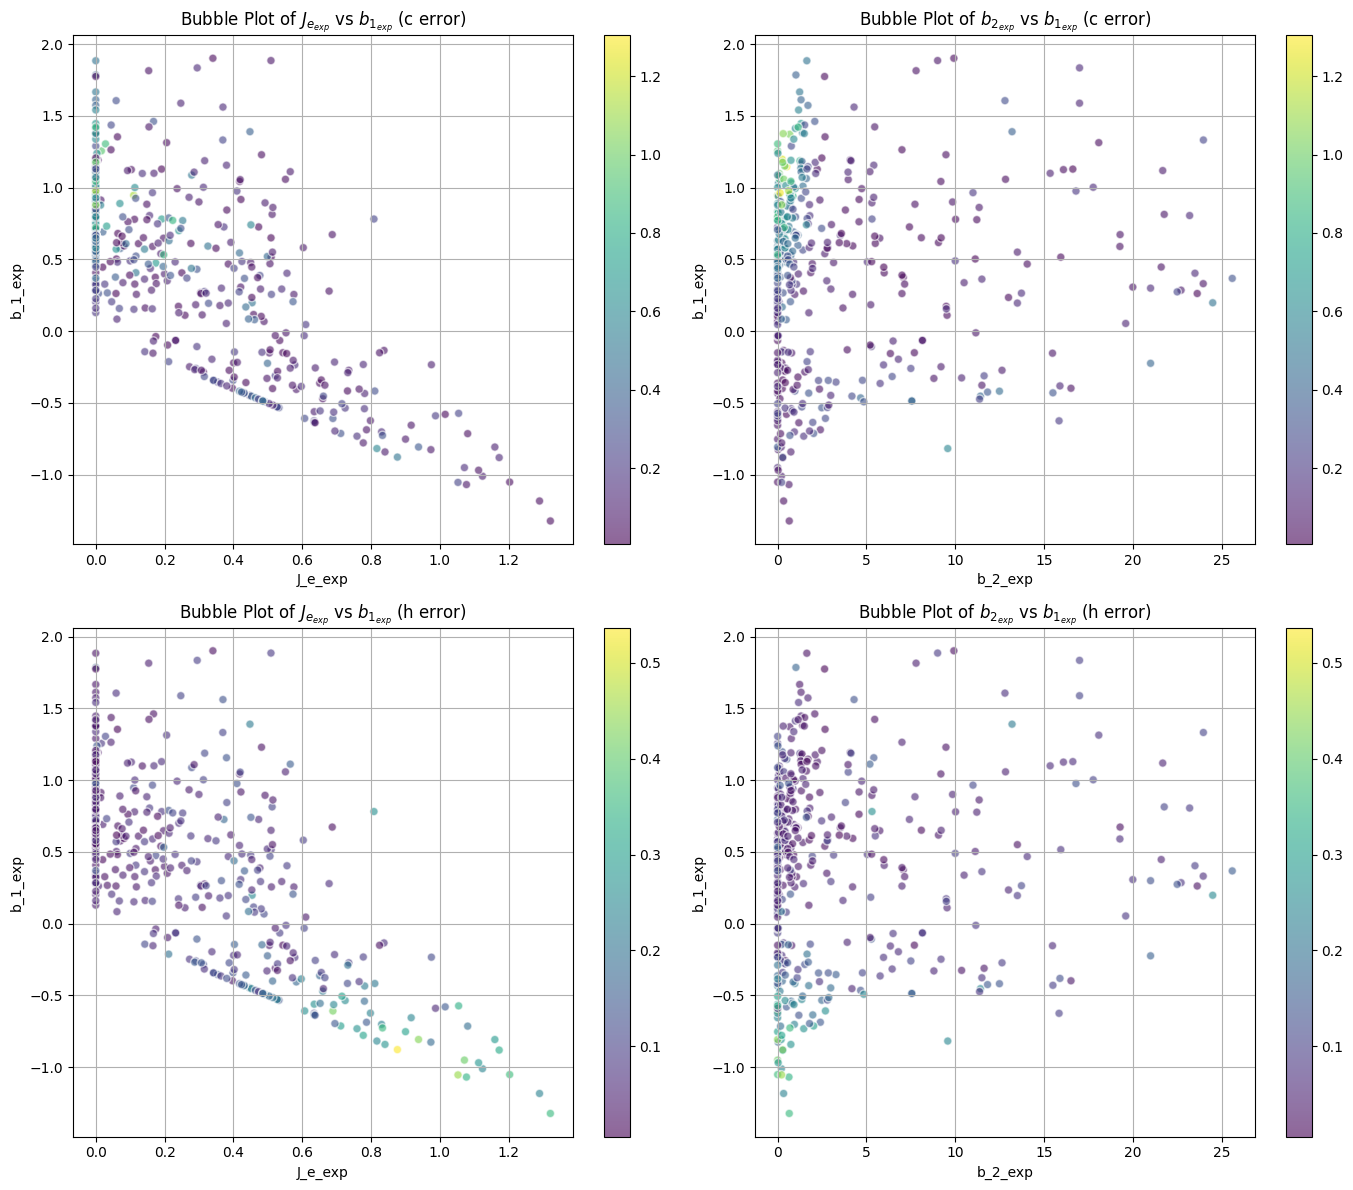

In [35]:
rrmse_c_f = rrmse_c_ffn_experimental[mask]
rrmse_h_f = rrmse_h_ffn_experimental[mask]

# same plotting code with filtered data
fig, ax = plt.subplots(2, 2, figsize=(14, 12))

scatter_0 = ax[0,0].scatter(
    J_e_exp_f, b_1_exp_f,
    c=rrmse_c_f, alpha=0.6, edgecolors='w'
)
fig.colorbar(scatter_0, ax=ax[0,0])
ax[0,0].set_xlabel('J_e_exp')
ax[0,0].set_ylabel('b_1_exp')
ax[0,0].set_title(r'Bubble Plot of $J_{e_{exp}}$ vs $b_{1_{exp}}$ (c error)')
ax[0,0].grid(True)

scatter_2 = ax[0,1].scatter(
    b_2_exp_f, b_1_exp_f,
    c=rrmse_c_f, alpha=0.6, edgecolors='w'
)
fig.colorbar(scatter_2, ax=ax[0,1])
ax[0,1].set_xlabel('b_2_exp')
ax[0,1].set_ylabel('b_1_exp')
ax[0,1].set_title(r'Bubble Plot of $b_{2_{exp}}$ vs $b_{1_{exp}}$ (c error)')
ax[0,1].grid(True)

scatter_0 = ax[1,0].scatter(
    J_e_exp_f, b_1_exp_f,
    c=rrmse_h_f, alpha=0.6, edgecolors='w'
)

fig.colorbar(scatter_0, ax=ax[1,0])
ax[1,0].set_xlabel('J_e_exp')
ax[1,0].set_ylabel('b_1_exp')
ax[1,0].set_title(r'Bubble Plot of $J_{e_{exp}}$ vs $b_{1_{exp}}$ (h error)')
ax[1,0].grid(True)


scatter_2 = ax[1,1].scatter(
    b_2_exp_f, b_1_exp_f,
    c=rrmse_h_f, alpha=0.6, edgecolors='w'
)

fig.colorbar(scatter_2, ax=ax[1,1])
ax[1,1].set_xlabel('b_2_exp')
ax[1,1].set_ylabel('b_1_exp')
ax[1,1].set_title(r'Bubble Plot of $b_{2_{exp}}$ vs $b_{1_{exp}}$ (h error)')
ax[1,1].grid(True)

plt.tight_layout()
plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/final/bubble_plots_experimental_filtered_ffn.pdf", dpi=600)
plt.show()

In [36]:
t = np.linspace(0, 1, 601)

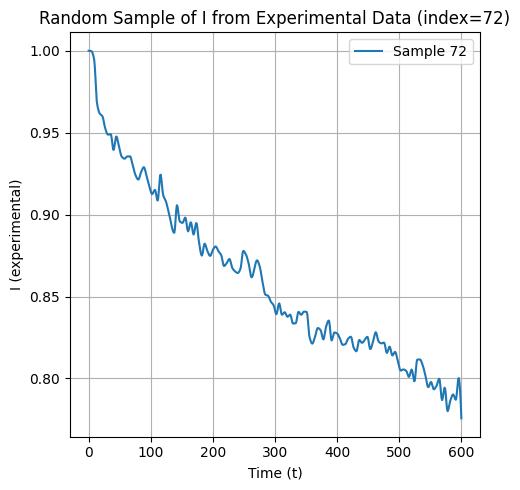

In [37]:
# Select a random index from the experimental data
idx = np.random.randint(len(I_scaled_interp))

plt.figure(figsize=(5, 5))
plt.plot(I_scaled_interp[idx], label=f'Sample {idx}')
plt.xlabel('Time (t)')
plt.ylabel('I (experimental)')
plt.title(f'Random Sample of I from Experimental Data (index={idx})')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [38]:
mean_rrmse_ffn = np.mean(rrmse_c_ffn)
median_rrmse_ffn = np.median(rrmse_c_ffn)
iqr_rrmse_ffn = np.percentile(rrmse_c_ffn, 75) - np.percentile(rrmse_c_ffn, 25)
percentile_90_rrmse_ffn = np.percentile(rrmse_c_ffn, 90)

print(f"Mean: {mean_rrmse_ffn:.4f}")
print(f"Median: {median_rrmse_ffn:.4f}")
print(f"IQR: {iqr_rrmse_ffn:.4f}")
print(f"90th percentile: {percentile_90_rrmse_ffn:.4f}")

Mean: 0.0365
Median: 0.0237
IQR: 0.0319
90th percentile: 0.0802


In [39]:
mean_rrmse_pca = np.mean(rrmse_c_pca)
median_rrmse_pca = np.median(rrmse_c_pca)
iqr_rrmse_pca = np.percentile(rrmse_c_pca, 75) - np.percentile(rrmse_c_pca, 25)
percentile_90_rrmse_pca = np.percentile(rrmse_c_pca, 90)

print(f"Mean: {mean_rrmse_pca:.4f}")
print(f"Median: {median_rrmse_pca:.4f}")
print(f"IQR: {iqr_rrmse_pca:.4f}")
print(f"90th percentile: {percentile_90_rrmse_pca:.4f}")

Mean: 0.0362
Median: 0.0209
IQR: 0.0394
90th percentile: 0.0890


In [40]:
mean_rrmse_enh = np.mean(rrmse_c_enhanced_pca)
median_rrmse_enh = np.median(rrmse_c_enhanced_pca)
iqr_rrmse_enh = np.percentile(rrmse_c_enhanced_pca, 75) - np.percentile(rrmse_c_enhanced_pca, 25)
percentile_90_rrmse_enh = np.percentile(rrmse_c_enhanced_pca, 90)

print(f"Mean: {mean_rrmse_enh:.4f}")
print(f"Median: {median_rrmse_enh:.4f}")
print(f"IQR: {iqr_rrmse_enh:.4f}")
print(f"90th percentile: {percentile_90_rrmse_enh:.4f}")

Mean: 0.0721
Median: 0.0568
IQR: 0.0625
90th percentile: 0.1396


In [41]:
mean_rrmse_ffn_h = np.mean(rrmse_h_ffn)
median_rrmse_ffn_h = np.median(rrmse_h_ffn)
iqr_rrmse_ffn_h = np.percentile(rrmse_h_ffn, 75) - np.percentile(rrmse_h_ffn, 25)
percentile_90_rrmse_ffn_h = np.percentile(rrmse_h_ffn, 90)

print(f"Mean: {mean_rrmse_ffn_h:.4f}")
print(f"Median: {median_rrmse_ffn_h:.4f}")
print(f"IQR: {iqr_rrmse_ffn_h:.4f}")
print(f"90th percentile: {percentile_90_rrmse_ffn_h:.4f}")

Mean: 0.0331
Median: 0.0258
IQR: 0.0262
90th percentile: 0.0651


In [42]:
mean_rrmse_pca_h = np.mean(rrmse_h_pca)
median_rrmse_pca_h = np.median(rrmse_h_pca)
iqr_rrmse_pca_h = np.percentile(rrmse_h_pca, 75) - np.percentile(rrmse_h_pca, 25)
percentile_90_rrmse_pca_h = np.percentile(rrmse_h_pca, 90)

print(f"Mean: {mean_rrmse_pca_h:.4f}")
print(f"Median: {median_rrmse_pca_h:.4f}")
print(f"IQR: {iqr_rrmse_pca_h:.4f}")
print(f"90th percentile: {percentile_90_rrmse_pca_h:.4f}")

Mean: 0.0307
Median: 0.0218
IQR: 0.0273
90th percentile: 0.0646


In [43]:
mean_rrmse_enh_h = np.mean(rrmse_h_enhanced_pca)
median_rrmse_enh_h = np.median(rrmse_h_enhanced_pca)
iqr_rrmse_enh_h = np.percentile(rrmse_h_enhanced_pca, 75) - np.percentile(rrmse_h_enhanced_pca, 25)
percentile_90_rrmse_enh_h = np.percentile(rrmse_h_enhanced_pca, 90)

print(f"Mean: {mean_rrmse_enh_h:.4f}")
print(f"Median: {median_rrmse_enh_h:.4f}")
print(f"IQR: {iqr_rrmse_enh_h:.4f}")
print(f"90th percentile: {percentile_90_rrmse_enh_h:.4f}")

Mean: 0.0521
Median: 0.0462
IQR: 0.0263
90th percentile: 0.0834
